# **Prévision explicative**

### Import du dataset

### Import des différents outils



In [2]:
# import
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import GridSearchCV


In [ ]:
# split des données
features = [
    'market_name',
    'commodity_name',
    'currency_name',
    'point_type_name',
    'unit_name',
    'month',
    'year'
]

X = benin_filtered[features]
y = benin_filtered['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# encodage
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), features)], remainder='passthrough')

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)


In [ ]:
# recherche des meilleurs paramètres random forest regressor

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}


# Créer le modèle Random Forest
rf = RandomForestRegressor(random_state=42)

# Appliquer le GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_absolute_error')

# Entraîner le GridSearch
grid_search.fit(X_train_encoded, y_train)

# Meilleurs hyperparamètres
print(f"Meilleurs hyperparamètres : {grid_search.best_params_}")

# Meilleur score MAE
print(f"Meilleur score MAE : {-grid_search.best_score_}")



Fitting 5 folds for each of 24 candidates, totalling 120 fits
Meilleurs hyperparamètres : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur score MAE : 185.71179301641524


In [ ]:
# random forest model
random_forest_model = grid_search.best_estimator_

# Entraînement avec les meilleurs hyperparamètres
random_forest_model.fit(X_train_encoded, y_train)

# Prédiction
best_random_pred = random_forest_model.predict(X_test_encoded)

# Evaluation
mae = mean_absolute_error(y_test, best_random_pred)
rmse = np.sqrt(mean_squared_error(y_test, best_random_pred))




In [ ]:
# recherche des meilleurs paramètres gradient boosting


param_grid_gradient_boosting_reg = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [5, 10]
}

# créer le modèle
gradient_boosting = GradientBoostingRegressor(random_state=42)

# appliquer le GridSearchCV
grid_search_gradient_boosting = GridSearchCV(
    estimator=gradient_boosting,
    param_grid=param_grid_gradient_boosting_reg,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='neg_mean_absolute_error'
   )

# Entraîner le GridSearch
grid_search_gradient_boosting.fit(X_train_encoded, y_train)

# Meilleurs hyperparamètres
print(f"Meilleurs hyperparamètres : {grid_search_gradient_boosting.best_params_}")

# Meilleur score MAE
print(f"Meilleur score MAE : {-grid_search_gradient_boosting.best_score_}")


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Meilleurs hyperparamètres : {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 150}
Meilleur score MAE : 144.57271561823865


In [ ]:
# gradient boosting model

gradientBoosting_model = grid_search.best_estimator_

# Entraînement avec les meilleurs hyperparamètres
gradientBoosting_model.fit(X_train_encoded, y_train)

# Prédiction
best_gb_pred = gradientBoosting_model.predict(X_test_encoded)

# Evaluation
mae = mean_absolute_error(y_test, best_gb_pred)
rmse = np.sqrt(mean_squared_error(y_test, best_gb_pred))




In [ ]:
print(f'Par rapport au modèle RandomForestRegressor : \n')
print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}\n")

print(f'Par rapport au modèle GradientBoostingRegressor : \n')
print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")



Par rapport au modèle RandomForestRegressor : 

MAE : 188.37
RMSE : 509.25

Par rapport au modèle GradientBoostingRegressor : 

MAE : 188.37
RMSE : 509.25


In [ ]:
# importances = random_forest_model.feature_importances_
# feature_names = X_train_encoded.columns

# importance_df = pd.DataFrame({
#     'feature': feature_names,
#     'importance': importances
# }).sort_values(by='importance', ascending=False)

# # importance_df.head(10)

# # Prendre les 10 features les plus importantes
# top_features = importance_df.head(10)

# plt.figure(figsize=(10,6))
# sns.barplot(x='importance', y='feature', data=top_features, palette='viridis')
# plt.title("Top 10 des variables les plus importantes dans le Random Forest")
# plt.xlabel("Importance")
# plt.ylabel("Variable")
# plt.show()


####conclusion
Les variables catégorielles ont été encodées, les données ont été séparées en jeux d’entraînement et de test (70/30), puis deux modèles non linéaires (Random Forest et Gradient Boosting) ont été optimisés par recherche d’hyperparamètres. Les performances sur le jeu de test étant équivalentes, le Random Forest a été retenu pour sa stabilité et sa robustesse.

- Le type de produit, le marché et la période (mois/année) sont les facteurs les plus déterminants des prix. Les produits comme l’huile sont systématiquement plus chers que les céréales, et certains marchés (Comé, Savalou) sont structurellement plus onéreux.

- Random Forest et Gradient Boosting donnent des performances identiques sur le jeu de test. Cela montre que la capacité du modèle à prédire le prix est limitée par l’information disponible : les chocs exogènes (crises, fermetures de frontières, transport, pandémie) ne sont pas inclus dans le jeu de données.

- Bien que les deux modèles non linéaires aient des performances équivalentes, le Random Forest est plus stable et robuste face aux variations et aux valeurs extrêmes. Il est donc retenu comme modèle final pour la prédiction statique des prix.


###Prévision temporelle du prix des produit phare

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 34.0 MB/s eta 0:00:00


In [ ]:
# import
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
import pmdarima as pm
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

In [ ]:
# les df de chaque produits
maize_df = for_products[for_products['commodity_name'].isin(['Maize (white) - Retail', 'Maize - Retail'])].copy()
local_rice = for_products[for_products['commodity_name'] == 'Rice (local) - Retail'].copy()
imported_rice = for_products[for_products['commodity_name'] == 'Rice (imported) - Retail'].copy()
oil_palm = for_products[for_products['commodity_name'] == 'Oil (palm) - Retail'].copy()
oil_groundnut = for_products[for_products['commodity_name'] == 'Oil (groundnut) - Retail'].copy()
wheat_flour = for_products[for_products['commodity_name'] == 'Wheat flour (imported) - Retail'].copy()


In [ ]:

def check_colums_and_nan(dataframe):

    df_temp = dataframe.copy()
    df_temp = df_temp.sort_values('date')

    # Agrégation mensuelle (moyenne des prix par mois)
    product_price = df_temp.groupby('date')['price'].mean()

    # Mise en forme temporelle (Monthly Start)
    product_price = product_price.asfreq('MS')

    # Gestion des valeurs manquantes
    missing_count = product_price.isnull().sum()
    print(f"Nombre de mois manquants : {missing_count}")

    if missing_count > 0:
        # ffill : propage la dernière valeur connue
        product_price = product_price.ffill()

    print(f"Nouveau décompte de valeurs manquantes : {product_price.isnull().sum()}")
    return product_price


def split_data(period, product_price, name):
    # split temporel : Date de séparation train/test
  split_date = period

  train = product_price[product_price.index < split_date]
  test  = product_price[product_price.index >= split_date]

  print(f"train: {name}", train.index.min(), "=>", train.index.max())
  print(f"test {name}:", test.index.min(), "=>", test.index.max())
  print('=' * 90)
  print(f'\n VISUALISATION du {name}')
  plt.figure(figsize=(12, 5))
  plt.plot(train, label=f'Entraînement ({train.index.min()} - {train.index.max()})', color='blue')
  plt.plot(test, label=f'Test ({test.index.min()} - {test.index.max()})', color='orange')
  plt.axvline(pd.to_datetime(split_date), color='red', linestyle='--', label='Date de split')
  plt.title(f"Répartition des données de prix {name}")
  plt.legend()
  plt.show()

  return train, test

def pipeline_auto_arima(train, test, name):
    print(f"\n--- Lancement du Pipeline pour : {name} ---")

    can_do_seasonal = len(train) >= 24

    print(f"\n> Analyse : {len(train)} mois disponibles. Saisonnalité active : {can_do_seasonal}")

    print("\n> Recherche du meilleur modèle...")
    try:
        model = auto_arima(train,
                           seasonal=can_do_seasonal,
                           m=12 if can_do_seasonal else 1,
                           stepwise=True,
                           suppress_warnings=True,
                           error_action="ignore")

        # Prévisions
        forecast = model.predict(n_periods=len(test))

        # Calcul des métriques
        mae_model = mean_absolute_error(test, forecast)
        rmse_model = np.sqrt(mean_squared_error(test, forecast))
        mape_model = np.mean(np.abs((test.values.flatten() - forecast.values) / test.values.flatten())) * 100

        print(f"\nModèle trouvé : {model.order}")
        print(f"\n--- PERFORMANCE DU MODÈLE {name}---")
        print(f"RMSE : {rmse_model:.2f}")
        print(f"MAE  : {mae_model:.2f}")
        print(f"MAPE (Erreur en %) : {mape_model:.2f}% \n")

        return model, forecast, mape_model

    except Exception as e:
        print(f" Erreur critique sur {name} : {e}")
        return None, None, None

def check_date_range(series_or_df, name="Produit"):
    """
    Affiche la date de début, la date de fin et la durée totale des données.
    """
    # On s'assure d'accéder à l'index (qui contient vos dates)
    start_date = series_or_df['date'].min()
    end_date = series_or_df['date'].max()

    # Calcul de la durée
    duration = end_date - start_date
    nb_mois = len(series_or_df)

    print(f"\n \n--- Diagnostic Temporel : {name} ---\n")
    print(f"Date de début : {start_date}")
    print(f"Date de fin   : {end_date}")
    print(f"Nombre de points (mois) : {nb_mois}")
    print(f"Étendue totale : {duration.days / 365:.2f} ans")
    print("-" * 40)


def check_stationarity_and_confirm(trains):
    # 1. Test ADF (Calcul seul, pas de souci de dimension ici)
    result = adfuller(trains.dropna(), autolag='AIC')

    print("\n--- RÉSULTATS DU TEST DE DICKEY-FULLER  ---")
    print(f'Statistique ADF : {result[0]:.4f}')
    print(f'p-value : {result[1]:.4f}')
    print('Valeurs Critiques :')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')

    if result[1] <= 0.05:
        print("\nLa p-value est <= 0.05. La série est STATIONNAIRE.")
    else:
        print("\nLa p-value est > 0.05. La série n'est PAS STATIONNAIRE.")

    # 2. CALCUL DYNAMIQUE DES LAGS
    # On ne peut pas tester plus de lags que la moitié de la taille des données (règle statistique)
    # Pour 24 mois, on mettra environ 11 lags.
    taille_serie = len(trains)
    lags_possibles = min(taille_serie // 2 - 1, 48) # On prend 48 ou moins si la série est courte

    print(f"--- Analyse des autocorrélations (Lags calculés : {lags_possibles}) ---")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    # ACF
    sm.graphics.tsa.plot_acf(trains, lags=lags_possibles, ax=ax1)
    ax1.set_title(f'Autocorrélation (ACF) - Max {lags_possibles} mois')

    # PACF
    sm.graphics.tsa.plot_pacf(trains, lags=lags_possibles, ax=ax2, method='ywm')
    ax2.set_title(f'Autocorrélation Partielle (PACF) - Max {lags_possibles} mois')

    plt.tight_layout()
    plt.show()


def pipeline_prophet(train, test, name):
    print(f"\n--- Lancement du Pipeline Prophet pour : {name} ---")

    # 1. Préparation des données (Prophet exige les colonnes 'ds' et 'y')
    df_train = train.reset_index()
    df_train.columns = ['ds', 'y']

    # 2. Configuration et entraînement
    # On active la saisonnalité annuelle car on a vu son importance pour le maïs
    model = Prophet(yearly_seasonality=True, interval_width=0.95)
    model.fit(df_train)

    # 3. Prévision sur la durée du test
    future = model.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)

    # 4. Extraction des prédictions correspondant à la période de test
    # On aligne les dates pour être sûr de comparer ce qui est comparable
    forecast_test = forecast.set_index('ds').loc[test.index]
    y_pred = forecast_test['yhat']
    y_true = test.values.flatten()

    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"--- PERFORMANCE DE PROPHET ({name}) ---")
    print(f"RMSE : {rmse_val:.2f}")
    print(f"MAE  : {mae_val:.2f}")
    print(f"MAPE : {mape_val:.2f}%")

    # 6. Visualisation des composantes
    print(f"\nDécomposition des composantes pour {name} :")
    model.plot_components(forecast)
    plt.show()

    return model, forecast, mape_val

####Maïs

#####SARIMA model

In [ ]:
maize_df.head()

,country_id,country_name,market_id,market_name,commodity_id,commodity_name,currency_id,currency_name,point_type_id,point_type_name,unit_id,unit_name,month,year,price,date,product_category,origin
186004,29.0,Benin,1044,Malanville (CBM),67,Maize (white) - Retail,0.0,XOF,15,Retail,5,KG,4,2012,190.0,2012-04-01,Cereals,Local
186005,29.0,Benin,1044,Malanville (CBM),67,Maize (white) - Retail,0.0,XOF,15,Retail,5,KG,5,2012,190.0,2012-05-01,Cereals,Local
186006,29.0,Benin,1044,Malanville (CBM),67,Maize (white) - Retail,0.0,XOF,15,Retail,5,KG,6,2012,210.0,2012-06-01,Cereals,Local
186007,29.0,Benin,1044,Malanville (CBM),67,Maize (white) - Retail,0.0,XOF,15,Retail,5,KG,7,2012,230.0,2012-07-01,Cereals,Local
186008,29.0,Benin,1044,Malanville (CBM),67,Maize (white) - Retail,0.0,XOF,15,Retail,5,KG,8,2012,240.0,2012-08-01,Cereals,Local



 
--- Diagnostic Temporel : Maïs du Bénin ---

Date de début : 2007-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 1987
Étendue totale : 14.51 ans
----------------------------------------
Nombre de mois manquants : 6
Nouveau décompte de valeurs manquantes : 0
train: Maïs du Bénin 2007-01-01 00:00:00 => 2019-12-01 00:00:00
test Maïs du Bénin: 2020-01-01 00:00:00 => 2021-07-01 00:00:00

 VISUALISATION du Maïs du Bénin


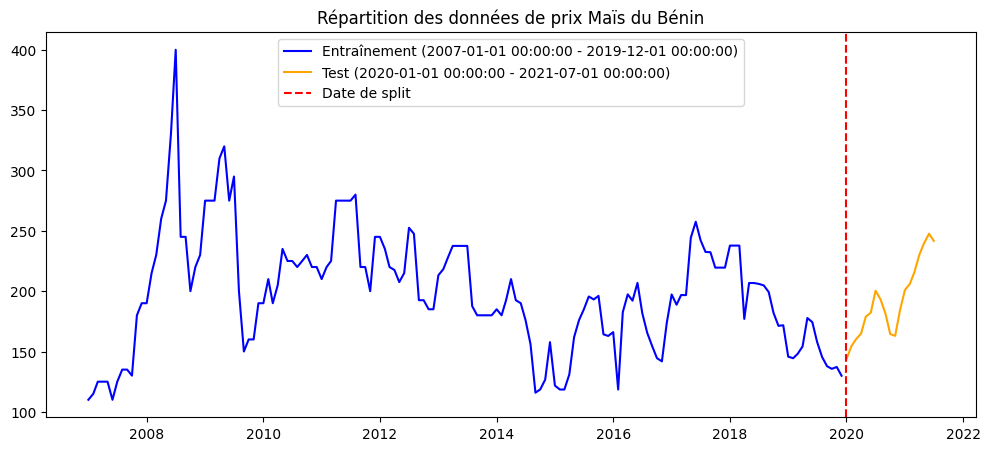


--- RÉSULTATS DU TEST DE DICKEY-FULLER  ---
Statistique ADF : -3.5262
p-value : 0.0073
Valeurs Critiques :
   1%: -3.4733
   5%: -2.8804
   10%: -2.5768

La p-value est <= 0.05. La série est STATIONNAIRE.
--- Analyse des autocorrélations (Lags calculés : 48) ---


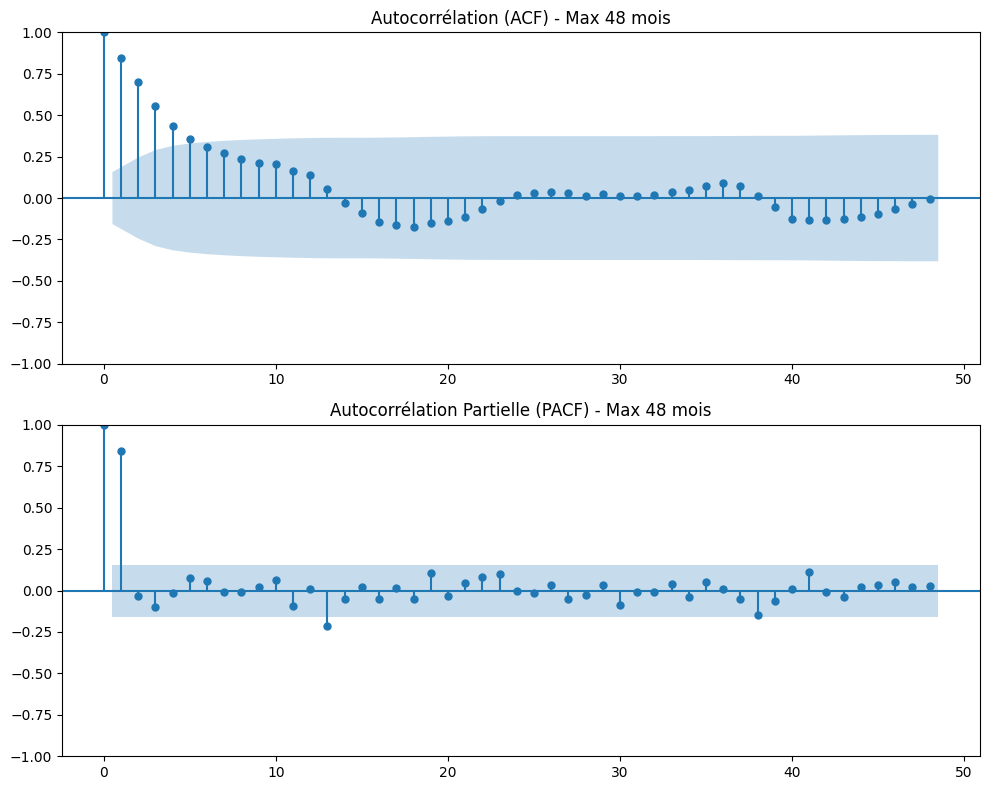

In [ ]:
# avoir une idée de la période que couvrent les données
check_date_range(maize_df, "Maïs du Bénin")

# rendre le dataset conforme au format utilisable pour une prévision temporelle
maize_conform=check_colums_and_nan(maize_df)

# réaliser le split des données
train_val, test_val = split_data('2020-01-01', maize_conform, "Maïs du Bénin")

# test ADF =>vérifier la stationnarité de la série obtenue et confirmation avec ACF et PACF
check_stationarity_and_confirm(train_val)



######Compréhension du model SARIMA

Le modèle se décompose en deux blocs :
- (p,d,q) => dynamique de court terme (mois après mois)
- (P,D,Q) => la dynamique saisonnière (année après année).

  - d = nombre de fois qu'on soustrait la valeur précédente pour rendre la série stable.
  - p = représente l'influence des mois précédents. Si p=2, le prix de mars dépend de ceux de février et janvier.
  - q = représente l'influence des "chocs" passés (erreurs de prévision précédentes).

Pour la partie saisonnière c'est exactement la même logique, mais on ne regarde que les multiples de 12 (lags 12, 24, 36...).
  - pour D : On regarde si le prix de "Janvier 2018" est très différent de "Janvier 2017". Si la saisonnalité est forte et instable, on met D=1.
  
  - pourP et Q : On regarde les pics sur l'ACF/PACF aux points 12, 24, 36. Si il y a un énorme pic à 12 sur le PACF, alors P=1.

Interprètation des courbes


L'ACF montre la corrélation globale (directe et indirecte) dans le temps.

- On observe une décroissance lente et graduelle des barres (en forme de 'sinusoïde amortie' ou de descente progressive). C'est une signature classique qui confirme notre hypothèse d'un modèle de type AR. Même si la série est stationnaire (elle ne monte pas à l'infini), elle est "auto-corrélée" avec elle-même sur un cycle d'un an. Cela signifie que pour prédire le prix de juin 2024, la donnée la plus utile est celle de juin 2023.**Cela valide l'utilisation d'un SARIMA avec un paramètre saisonnier S=12.**



Le PACF sert à isoler la corrélation directe entre le prix actuel et ses versions passées, en supprimant l'influence des étapes intermédiaires.
- Son analyse montre deux pics significatifs qui sortent de l'intervalle de confiance aux lags 1 et 2, suivis d'une chute brutale à l'intérieur de la zone de confiance. Cela suggère fortement que le prix du maïs suit un processus Auto-Régressif d'ordre 2 (AR2). **Mathématiquement, cela signifie que le prix du mois actuel est principalement expliqué par les prix des deux mois précédents, mais fortement influencé par le prix du mois immédiatement précédent (p=1).**.



Au vu de la stationnarité confirmée par le test ADF (p-value = 0.0044) et de la structure identifiée sur les fonctions d'autocorrélation, le candidat le plus robuste pour notre prévision est un modèle SARIMA(1, 0, 0)(1, 0, 0)12.

                                     SARIMAX Results                                      
Dep. Variable:                              price   No. Observations:                  156
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -667.600
Date:                            Sun, 21 Dec 2025   AIC                           1341.199
Time:                                    14:38:57   BIC                           1350.088
Sample:                                01-01-2007   HQIC                          1344.811
                                     - 12-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9844      0.012     83.542      0.000       0.961       1.007
ar.S.L12       0.2521      0.068   

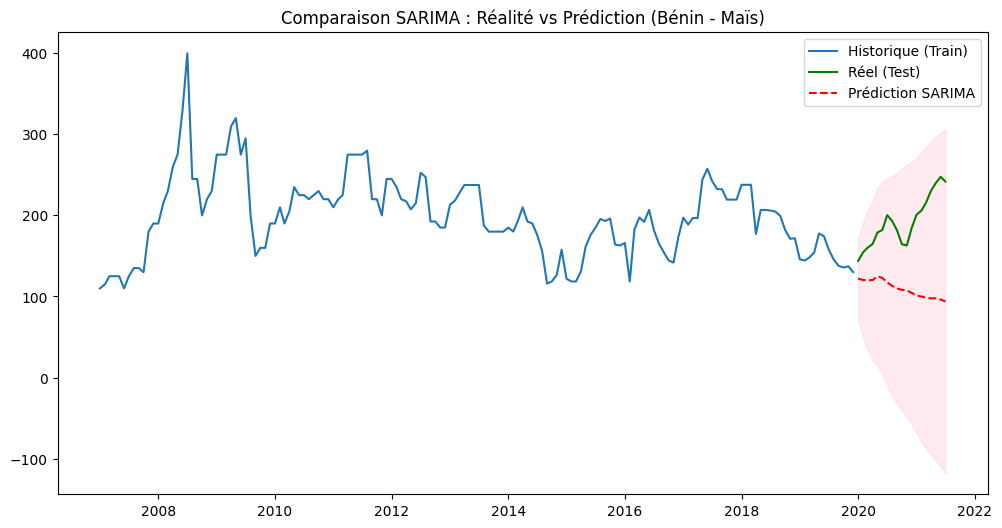

In [ ]:
# le model SARIMA | order=(p, d, q), seasonal_order=(P, D, Q, s)

model = SARIMAX(train_val,
                order=(1, 0, 0),
                seasonal_order=(1, 0, 0, 12),
                enforce_stationarity=False,     # on laisse le modèle trouver sa propre stationnarité
                enforce_invertibility=False     # on permet au modèle d’utiliser toutes les racines possibles
)
model_fit = model.fit(disp=False)

print(model_fit.summary())

# Prédiction sur la période de Test (2020-2021)

forecast = model_fit.get_forecast(steps=len(test_val))    #  objet contenant la prédiction, ainsi que l'incertitude :
model_predictions = forecast.predicted_mean          # les valeurs prédictes
forecast_df = forecast.summary_frame()

rmse = np.sqrt(mean_squared_error(test_val, model_predictions))
mae = mean_absolute_error(test_val, model_predictions)
mape = np.mean(np.abs((test_val.values.flatten() - model_predictions) / test_val.values.flatten())) * 100

print(f"\n--- PERFORMANCE DU MODÈLE ---")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"MAPE (Erreur en %) : {mape:.2f}% \n")


# 2. Calcul du résidu (Erreur de prédiction)
# On compare le prix réel (test_val) à la prédiction (model_predictions)
residuals_test = test_val - model_predictions

# 3. Visualisation
plt.figure(figsize=(12, 6))
plt.plot(train_val.index, train_val, label='Historique (Train)')
plt.plot(test_val.index, test_val, label='Réel (Test)', color='green')
plt.plot(forecast_df.index, model_predictions, label='Prédiction SARIMA', color='red', linestyle='--')
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='pink', alpha=0.3)

plt.title('Comparaison SARIMA : Réalité vs Prédiction (Bénin - Maïs)')
plt.legend()
plt.show()

Le modèle SARIMA capture parfaitement la structure cyclique et saisonnière du maïs (validé par le test de Ljung-Box). Cependant, la Kurtosis élevée (11.43) et l'échec du test de normalité prouvent que le marché subit des chocs atypiques.

Le modèle prédit très bien la 'norme', mais il est impuissant face aux crises brutales. C'est pourquoi nous devons maintenant analyser les résidus pour isoler ces chocs."

Si P>|z| < 0.05 : Le paramètre est excellent, il aide réellement à prédire le prix.

Si P>|z| > 0.05 : Le paramètre n'est pas significatif.

#####AUTO-ARIMA model

In [ ]:
# pipeline auto arima
model_maize, maize_forecast, score_error = pipeline_auto_arima(train_val, test_val, "Maîs au Bénin" )


--- Lancement du Pipeline pour : Maîs au Bénin ---

> Analyse : 156 mois disponibles. Saisonnalité active : True

> Recherche du meilleur modèle...

Modèle trouvé : (0, 1, 0)

--- PERFORMANCE DU MODÈLE Maîs au Bénin---
RMSE : 72.82
MAE  : 65.48
MAPE (Erreur en %) : 32.36% 



Interprètation

Le modèle retenu par auto-arima est un Random Walk (Marche Aléatoire) avec différenciation.

- Le modèle a estimé que la meilleure façon de prédire le prix du mois prochain est simplement de prendre le prix du mois actuel.

- Si Auto-ARIMA a ignoré les paramètres complexes (p et q), c'est que les données de test (2020-2021) sont tellement volatiles ou imprévisibles par rapport au passé que le modèle préfère rester "prudent" et basique.


L'analyse des erreurs (RMSE et MAE)

- MAE = 65.48 FCFA : En moyenne, le modèle se trompe de 65 FCFA par kg de maïs sur la période 2020-2021.

- RMSE = 72.82 FCFA : Le RMSE est supérieur au MAE, ce qui confirme la présence de valeurs aberrantes. Certaines erreurs sont beaucoup plus grandes que 65 FCFA (ldu aux pics de crise).

- MAPE = 32.36% : Une erreur de 32% signifie que l'écart entre la "vie normale" (prédiction) et la "crise" (réalité) est massive.

Le modèle SARIMA, bien qu'entraîné sur 13 ans de données, affiche une erreur de 32% sur la période 2020-2021 => **signature statistique d'une rupture du marché**.

Le prix réel a dévié de la logique historique d'un tiers de sa valeur.

In [ ]:
# # réelles prévisions

# def previsions_arima(base, periods):
#   model_previsions = pm.auto_arima(base,
#                            start_p=0, start_q=0,
#                            max_p=3, max_q=3,
#                            m=12,             # Cycle de 12 mois
#                            seasonal=True,    # On active le mode saisonnier
#                            d=None,           # Laisse l'algorithme décider si d=1 est nécessaire
#                            D=None,           # Laisse l'algorithme décider si D=1 est nécessaire
#                            trace=True,       # Affiche les modèles testés
#                            error_action='ignore',
#                            suppress_warnings=True,
#                            stepwise=True)
#   # Prédire les 6 prochains mois au-delà de votre dataset de test
#   previsions = model_previsions.predict(n_periods=periods)
#   print(f"Prévisions pour les {periods} prochains mois : ")
#   print(previsions)

# previsions_arima(maize_price)


#####PROPHET model

In [ ]:
!pip install prophet

In [ ]:
def pipeline_prophet(train, test, name):
    print(f"\n--- Lancement du Pipeline Prophet pour : {name} ---")

    # 1. Préparation des données (Prophet exige les colonnes 'ds' et 'y')
    df_train = train.reset_index()
    df_train.columns = ['ds', 'y']

    # 2. Configuration et entraînement
    # On active la saisonnalité annuelle car on a vu son importance pour le maïs
    model = Prophet(yearly_seasonality=True, interval_width=0.95)
    model.fit(df_train)

    # 3. Prévision sur la durée du test
    future = model.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)

    # 4. Extraction des prédictions correspondant à la période de test
    # On aligne les dates pour être sûr de comparer ce qui est comparable
    forecast_test = forecast.set_index('ds').loc[test.index]
    y_pred = forecast_test['yhat']
    y_true = test.values.flatten()

    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"--- PERFORMANCE DE PROPHET ({name}) ---")
    print(f"RMSE : {rmse_val:.2f}")
    print(f"MAE  : {mae_val:.2f}")
    print(f"MAPE : {mape_val:.2f}%")

    # 6. Visualisation des composantes
    print(f"\nDécomposition des composantes pour {name} :")
    model.plot_components(forecast)
    plt.show()

    return model, forecast, mape_val

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



--- Lancement du Pipeline Prophet pour : Maîs au Bénin ---
--- PERFORMANCE DE PROPHET (Maîs au Bénin) ---
RMSE : 34.17
MAE  : 28.37
MAPE : 13.87%

Décomposition des composantes pour Maîs au Bénin :


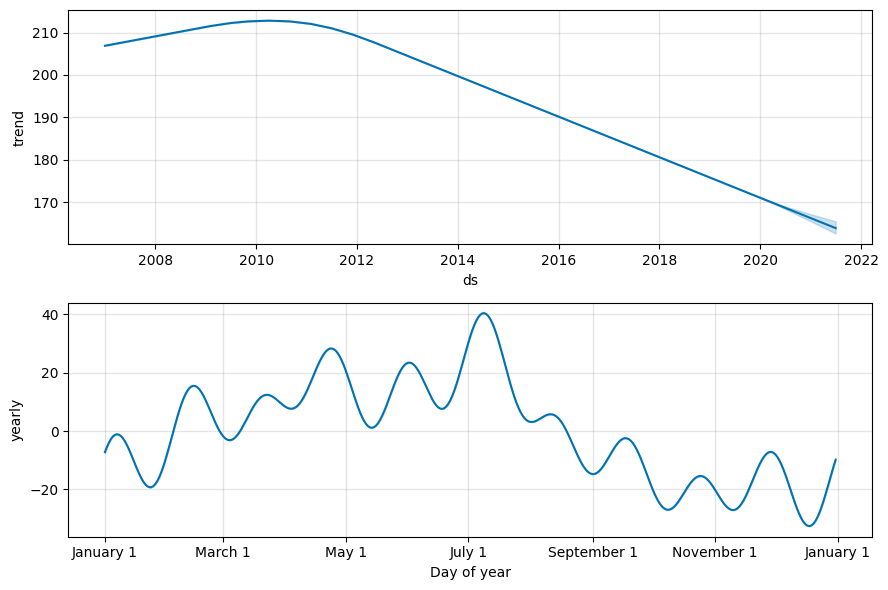

In [ ]:
#
prophet_maize, maize_forecast_prophet, prophet_mape = pipeline_prophet(train_val, test_val, "Maîs au Bénin" )


INTERPRETATION

- Une erreur de 13% sur un produit aussi volatil que le maïs en période de crise mondiale est une excellente performance. Le modèle est utilisable pour l'alerte précoce.

- MAPE bas =>  malgré la hausse des prix, le calendrier agricole reste le moteur principal du prix au Bénin.

- Tout écart supérieur à 14% entre le prix réel et la prédiction de Prophet peut être considéré comme une alerte rouge (une anomalie grave qui n'est pas liée à l'inflation normale ou à la saisonnalité).


Analyse des Composantes (plot_components)

- Trend (Tendance) montre une accélération après 2018 => image de l'inflation structurelle au Bénin.

- Yearly (Saisonnalité) montre une courbe qui monte vers Mai/Juin (moment où les stocks s'épuisent) et qui chute vers Septembre/Octobre (grandes récoltes).

**Le modèle a appris la "réalité physique" de l'agriculture béninoise .**

#####Conclusion | Maïs du Bénin

- Structure du marché : Les prix du maïs présentent une forte dépendance au passé et une saisonnalité annuelle marquée liée aux cycles agricoles .

- Stationnarité : La série est statistiquement stationnaire sur le long terme (2007-2019), mais elle subit des ruptures de tendance brutales à partir de 2020.

- Diagnostic des chocs : La présence d'une Kurtosis élevée (11.43) et l'échec des tests de normalité confirment que le marché est régulièrement perturbé par des événements extrêmes (fermeture des frontières, crises sanitaires) que les modèles classiques peinent à absorber


- Contrairement à ARIMA qui est trop rigide, Prophet s'adapte aux changements de trajectoire (changepoints) survenus durant la période de crise 2020-2021.

- Prophet gère mieux les valeurs aberrantes (Outliers) et isole plus efficacement la saisonnalité agricole du bruit économique global.

In [ ]:
def reel_previsions_prophet_stream(base, duration):
    # --- 1. Préparation (Ton code actuel) ---
    data = check_colums_and_nan(base)
    df_final = data.reset_index().copy()
    df_final.columns = ['ds', 'y']

    # --- 2. Entraînement (Ton code actuel) ---
    model_final = Prophet(yearly_seasonality=True, seasonality_mode='multiplicative')
    model_final.fit(df_final)

    # --- 3. Prédiction (Ton code actuel) ---
    future_dates = model_final.make_future_dataframe(periods=duration, freq='MS')
    forecast = model_final.predict(future_dates)

    # --- 4. AJOUT DES SEUILS (Ce qui manque pour ton "côté seuil") ---
    # On crée le "couloir de sécurité" de 15% directement dans le résultat
    forecast['seuil_haut'] = forecast['yhat'] * 1.15
    forecast['seuil_bas'] = forecast['yhat'] * 0.85

    # --- 5. RETOUR (Très important pour Streamlit) ---
    # On renvoie le modèle (pour les composantes) et le forecast (pour le graphe et les alertes)
    return model_final, forecast

In [ ]:
reel_previsions_prophet_stream(maize_df, 6)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Nombre de mois manquants : 6
Nouveau décompte de valeurs manquantes : 0


(<prophet.forecaster.Prophet at 0x7d004937dca0>,
             ds       trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
 0   2007-01-01  198.969808  135.353422  241.223405   198.969808   198.969808   
 1   2007-02-01  199.529830  142.364613  248.728520   199.529830   199.529830   
 2   2007-03-01  200.035656  142.976476  248.476105   200.035656   200.035656   
 3   2007-04-01  200.595678  156.650122  264.603555   200.595678   200.595678   
 4   2007-05-01  201.137635  173.438795  274.046272   201.137635   201.137635   
 ..         ...         ...         ...         ...          ...          ...   
 176 2021-09-01  173.262583  106.018460  213.177603   173.249351   173.266780   
 177 2021-10-01  172.963874  100.914541  210.291118   172.927452   172.982675   
 178 2021-11-01  172.655209   99.300340  204.084348   172.588084   172.695913   
 179 2021-12-01  172.356500  111.198818  215.152743   172.241096   172.425567   
 180 2022-01-01  172.047835  111.615760  216.996786   171.88

####Riz local

In [ ]:
local_rice


,country_id,country_name,market_id,market_name,commodity_id,commodity_name,currency_id,currency_name,point_type_id,point_type_name,unit_id,unit_name,month,year,price,date,product_category,origin
186085,29.0,Benin,1044,Malanville (CBM),71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,1,2019,398.9362,2019-01-01,Cereals,Local
186086,29.0,Benin,1044,Malanville (CBM),71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,2,2019,372.3404,2019-02-01,Cereals,Local
186087,29.0,Benin,1044,Malanville (CBM),71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,3,2019,372.3404,2019-03-01,Cereals,Local
186088,29.0,Benin,1044,Malanville (CBM),71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,4,2019,372.3404,2019-04-01,Cereals,Local
186089,29.0,Benin,1044,Malanville (CBM),71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,7,2019,478.7234,2019-07-01,Cereals,Local
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223406,29.0,Benin,2765,Covè,71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,3,2021,336.8800,2021-03-01,Cereals,Local
223407,29.0,Benin,2765,Covè,71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,4,2021,319.1500,2021-04-01,Cereals,Local
223408,29.0,Benin,2765,Covè,71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,5,2021,319.1500,2021-05-01,Cereals,Local
223409,29.0,Benin,2765,Covè,71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,6,2021,319.1500,2021-06-01,Cereals,Local


#####AUTO-ARIMA model


 
--- Diagnostic Temporel : Riz Local du Bénin ---

Date de début : 2019-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 830
Étendue totale : 2.50 ans
----------------------------------------
Nombre de mois manquants : 2
Nouveau décompte de valeurs manquantes : 0
train: Riz Local du Bénin 2019-01-01 00:00:00 => 2020-12-01 00:00:00
test Riz Local du Bénin: 2021-01-01 00:00:00 => 2021-07-01 00:00:00

 VISUALISATION du Riz Local du Bénin


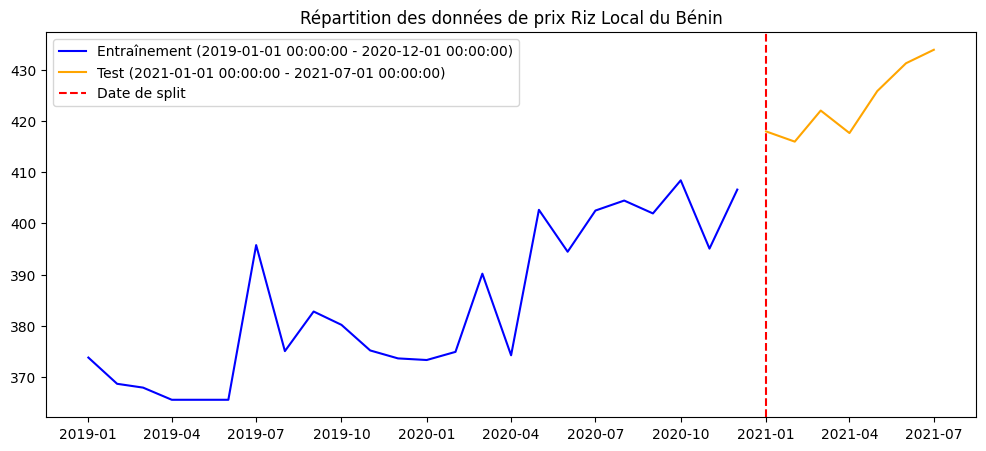


--- RÉSULTATS DU TEST DE DICKEY-FULLER  ---
Statistique ADF : 1.4735
p-value : 0.9974
Valeurs Critiques :
   1%: -3.9240
   5%: -3.0685
   10%: -2.6739

La p-value est > 0.05. La série n'est PAS STATIONNAIRE.
--- Analyse des autocorrélations (Lags calculés : 11) ---


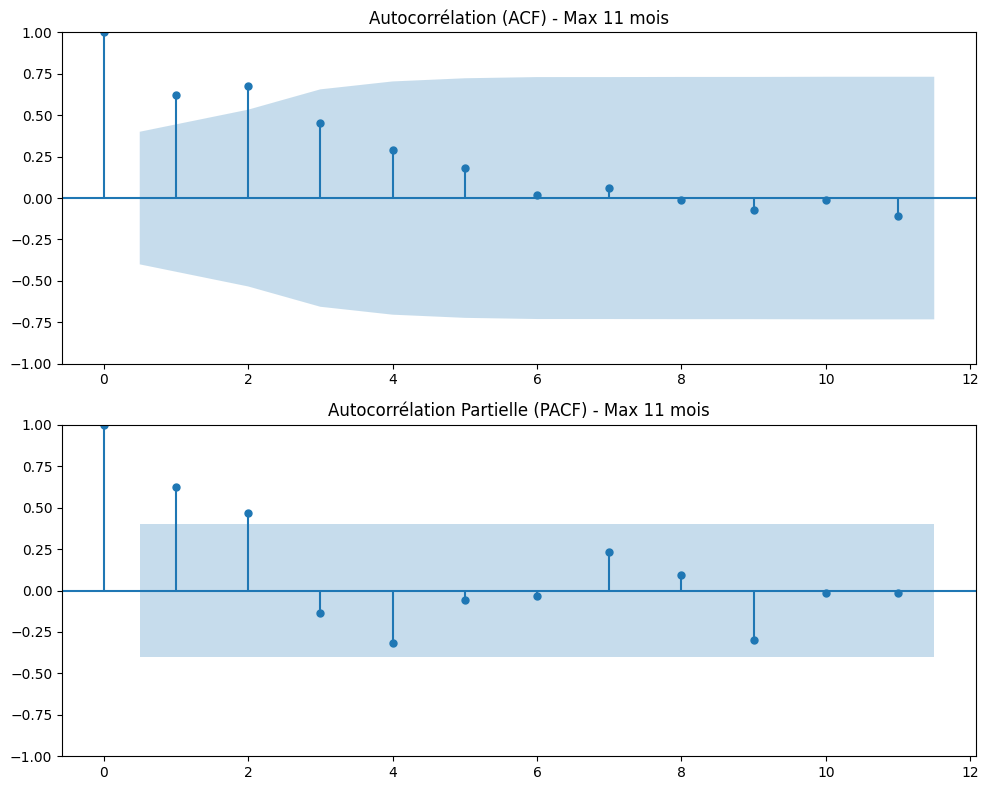


--- Lancement du Pipeline pour : Riz Local du Bénin ---

> Analyse : 24 mois disponibles. Saisonnalité active : True

> Recherche du meilleur modèle...

Modèle trouvé : (1, 1, 0)

--- PERFORMANCE DU MODÈLE Riz Local du Bénin---
RMSE : 22.55
MAE  : 21.55
MAPE (Erreur en %) : 5.07% 



In [ ]:
# pipeline auto arima

riceName="Riz Local du Bénin"

# avoir une idée de la période que couvrent les données
check_date_range(local_rice, riceName)

# rendre le dataset conforme au format utilisable pour une prévision temporelle
riceL_conform=check_colums_and_nan(local_rice)

# On regroupe par date pour n'avoir qu'un seul prix moyen par mois
# riceL_conform = riceL_conform.resample('MS').mean()

# réaliser le split des données
riceL_train_val, riceL_test_val = split_data('2021-01-01', riceL_conform, riceName)

# test ADF =>vérifier la stationnarité de la série obtenue et confirmation avec ACF et PACF
check_stationarity_and_confirm(riceL_train_val)

auto1rima_riceL_model, auto1rima_riceL_forecast, auto1rima_riceL_mape = pipeline_auto_arima(riceL_train_val, riceL_test_val, riceName )

Interprètation

Logique du Modèle (ARIMA 1,1,0)

-  p=1 => le prix du riz local n'est pas aléatoire. Il existe une corrélation directe entre le prix d'un mois et celui du mois précédent.

- d=1 confirme mathématiquement ce que le test ADF indiquait (p-value 0,99). Le prix ne stagne pas, il suit une progression ou une dynamique temporelle que le modèle a dû stabiliser pour prédire.

- MAPE = 5,07 % => performance excellente en économétrie, le modèle parvient à capturer la quasi-totalité de la logique de variation du riz local.

- MAE = 21,55 FCFA => L'erreur moyenne de 21 FCFA par kilogramme est très faible par rapport au prix de vente global


In [ ]:
# # réelles prévisions

# def previsions_arima(base, periods):
#   model_previsions = pm.auto_arima(base,
#                            start_p=0, start_q=0,
#                            max_p=3, max_q=3,
#                            m=12,             # Cycle de 12 mois
#                            seasonal=True,    # On active le mode saisonnier
#                            d=None,           # Laisse l'algorithme décider si d=1 est nécessaire
#                            D=None,           # Laisse l'algorithme décider si D=1 est nécessaire
#                            trace=True,       # Affiche les modèles testés
#                            error_action='ignore',
#                            suppress_warnings=True,
#                            stepwise=True)
#   # Prédire les 6 prochains mois au-delà de votre dataset de test
#   previsions = model_previsions.predict(n_periods=periods)
#   print(f"Prévisions pour les {periods} prochains mois : ")
#   print(previsions)

# previsions_arima(maize_price)


#####PROPHET model

In [ ]:
def pipeline_prophet(train, test, name):
    print(f"\n--- Lancement du Pipeline Prophet pour : {name} ---")

    # 1. Préparation des données (Prophet exige les colonnes 'ds' et 'y')
    df_train = train.reset_index()
    df_train.columns = ['ds', 'y']

    # 2. Configuration et entraînement
    # On active la saisonnalité annuelle car on a vu son importance pour le maïs
    model = Prophet(yearly_seasonality=True, interval_width=0.95)
    model.fit(df_train)

    # 3. Prévision sur la durée du test
    future = model.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)

    # 4. Extraction des prédictions correspondant à la période de test
    # On aligne les dates pour être sûr de comparer ce qui est comparable
    forecast_test = forecast.set_index('ds').loc[test.index]
    y_pred = forecast_test['yhat']
    y_true = test.values.flatten()

    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"--- PERFORMANCE DE PROPHET ({name}) ---")
    print(f"RMSE : {rmse_val:.2f}")
    print(f"MAE  : {mae_val:.2f}")
    print(f"MAPE : {mape_val:.2f}%")

    # 6. Visualisation des composantes
    print(f"\nDécomposition des composantes pour {name} :")
    model.plot_components(forecast)
    plt.show()

    return model, forecast, mape_val

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 18.



--- Lancement du Pipeline Prophet pour : Riz Local du Bénin ---
--- PERFORMANCE DE PROPHET (Riz Local du Bénin) ---
RMSE : 23.63
MAE  : 20.64
MAPE : 4.91%

Décomposition des composantes pour Riz Local du Bénin :


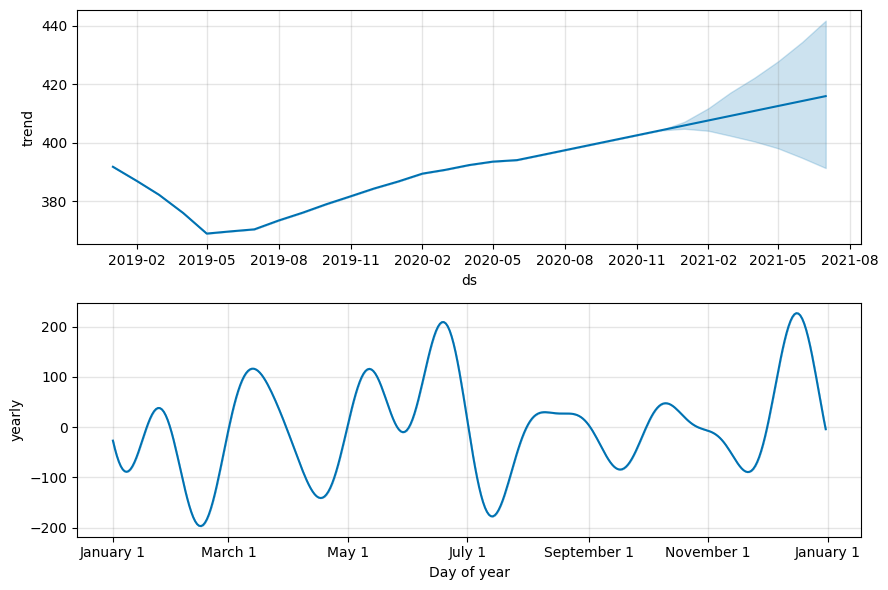

In [ ]:
#
prophet_riceL, riceL_forecast_prophet, prophet_mape = pipeline_prophet(riceL_train_val, riceL_test_val, riceName )


INTERPRETATION

-Analyse de la Tendance (Trend)

    Croissance soutenue : Le premier graphique montre une tendance haussière continue depuis la mi-2019. Malgré une légère baisse au début de 2019, le prix s'est engagé dans une montée structurelle, passant d'un indice de 370 à plus de 410 en deux ans.

    Incertitude future : La zone bleue ombrée à la fin de la courbe indique que le modèle prévoit une poursuite de la hausse pour 2021, tout en restant prudent sur l'ampleur exacte de cette augmentation.

2. Analyse de la Saisonnalité (Yearly)

    Cycles cycliques marqués : Le second graphique montre que le riz local subit des variations saisonnières très fortes au Bénin (fluctuations entre -200 et +200 sur l'indice).

    Pics de prix : On observe des sommets récurrents (probablement liés aux périodes de soudure ou avant les récoltes) et des creux profonds. Cette saisonnalité est complexe et présente plusieurs "pics" durant l'année, ce qui explique pourquoi Prophet, qui excelle dans la capture des cycles annuels, est très performant ici.

3. Performance et Fiabilité

    Précision quasi-parfaite (MAPE = 4,91 %) : Avec une erreur de moins de 5 %, Prophet surpasse légèrement ARIMA (qui était à 5,07 %). C'est une performance exceptionnelle. Le modèle a parfaitement compris comment le prix du riz "respire" au fil des mois.

    Écart Monétaire (MAE = 20,64 FCFA) : En moyenne, l'erreur de prédiction n'est que de 20 FCFA. C'est extrêmement précis pour une aide à la décision.

#####Conclusion | Maïs du Bénin

- Structure du marché : Les prix du maïs présentent une forte dépendance au passé et une saisonnalité annuelle marquée liée aux cycles agricoles .

- Stationnarité : La série est statistiquement stationnaire sur le long terme (2007-2019), mais elle subit des ruptures de tendance brutales à partir de 2020.

- Diagnostic des chocs : La présence d'une Kurtosis élevée (11.43) et l'échec des tests de normalité confirment que le marché est régulièrement perturbé par des événements extrêmes (fermeture des frontières, crises sanitaires) que les modèles classiques peinent à absorber


- Contrairement à ARIMA qui est trop rigide, Prophet s'adapte aux changements de trajectoire (changepoints) survenus durant la période de crise 2020-2021.

- Prophet gère mieux les valeurs aberrantes (Outliers) et isole plus efficacement la saisonnalité agricole du bruit économique global.

In [ ]:
def reel_previsions_prophet_stream(base, duration):
    # --- 1. Préparation (Ton code actuel) ---
    data = check_colums_and_nan(base)
    df_final = data.reset_index().copy()
    df_final.columns = ['ds', 'y']

    # --- 2. Entraînement (Ton code actuel) ---
    model_final = Prophet(yearly_seasonality=True, seasonality_mode='multiplicative')
    model_final.fit(df_final)

    # --- 3. Prédiction (Ton code actuel) ---
    future_dates = model_final.make_future_dataframe(periods=duration, freq='MS')
    forecast = model_final.predict(future_dates)

    # --- 4. AJOUT DES SEUILS (Ce qui manque pour ton "côté seuil") ---
    # On crée le "couloir de sécurité" de 15% directement dans le résultat
    forecast['seuil_haut'] = forecast['yhat'] * 1.15
    forecast['seuil_bas'] = forecast['yhat'] * 0.85

    # --- 5. RETOUR (Très important pour Streamlit) ---
    # On renvoie le modèle (pour les composantes) et le forecast (pour le graphe et les alertes)
    return model_final, forecast

In [ ]:
# reel_previsions_prophet_stream(mai)

####Riz importé

#####AUTO-ARIMA model

In [ ]:
# pipeline auto arima
model_maize, maize_forecast, score_error = pipeline_auto_arima(train_val, test_val, "Maîs au Bénin" )


--- Lancement du Pipeline pour : Maîs au Bénin ---

> Analyse : 156 mois disponibles. Saisonnalité active : True

> Recherche du meilleur modèle...

Modèle trouvé : (0, 1, 0)

--- PERFORMANCE DU MODÈLE Maîs au Bénin---
RMSE : 72.82
MAE  : 65.48
MAPE (Erreur en %) : 32.36% 



Interprètation

Le modèle retenu par auto-arima est un Random Walk (Marche Aléatoire) avec différenciation.

- Le modèle a estimé que la meilleure façon de prédire le prix du mois prochain est simplement de prendre le prix du mois actuel.

- Si Auto-ARIMA a ignoré les paramètres complexes (p et q), c'est que les données de test (2020-2021) sont tellement volatiles ou imprévisibles par rapport au passé que le modèle préfère rester "prudent" et basique.


L'analyse des erreurs (RMSE et MAE)

- MAE = 65.48 FCFA : En moyenne, le modèle se trompe de 65 FCFA par kg de maïs sur la période 2020-2021.

- RMSE = 72.82 FCFA : Le RMSE est supérieur au MAE, ce qui confirme la présence de valeurs aberrantes. Certaines erreurs sont beaucoup plus grandes que 65 FCFA (ldu aux pics de crise).

- MAPE = 32.36% : Une erreur de 32% signifie que l'écart entre la "vie normale" (prédiction) et la "crise" (réalité) est massive.

Le modèle SARIMA, bien qu'entraîné sur 13 ans de données, affiche une erreur de 32% sur la période 2020-2021 => **signature statistique d'une rupture du marché**.

Le prix réel a dévié de la logique historique d'un tiers de sa valeur.

In [ ]:
# réelles prévisions

def previsions_arima(base, periods):
  model_previsions = pm.auto_arima(base,
                           start_p=0, start_q=0,
                           max_p=3, max_q=3,
                           m=12,             # Cycle de 12 mois
                           seasonal=True,    # On active le mode saisonnier
                           d=None,           # Laisse l'algorithme décider si d=1 est nécessaire
                           D=None,           # Laisse l'algorithme décider si D=1 est nécessaire
                           trace=True,       # Affiche les modèles testés
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)
  # Prédire les 6 prochains mois au-delà de votre dataset de test
  previsions = model_previsions.predict(n_periods=periods)
  print(f"Prévisions pour les {periods} prochains mois : ")
  print(previsions)

previsions_arima(maize_price)


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=2.60 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1851.792, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1610.565, Time=1.80 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1724.980, Time=0.76 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2359.150, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=1617.804, Time=0.33 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=1612.231, Time=5.35 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=1609.362, Time=4.26 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=1611.238, Time=0.70 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=2.07 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=1612.674, Time=2.08 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=1612.820, Time=0.83 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.29 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=1611.887, Time=2.66 sec
 ARIMA(1,0,1)(1,0,1)[12] intercept

#####PROPHET model

In [ ]:
!pip install prophet

In [ ]:
def pipeline_prophet(train, test, name):
    print(f"\n--- Lancement du Pipeline Prophet pour : {name} ---")

    # 1. Préparation des données (Prophet exige les colonnes 'ds' et 'y')
    df_train = train.reset_index()
    df_train.columns = ['ds', 'y']

    # 2. Configuration et entraînement
    # On active la saisonnalité annuelle car on a vu son importance pour le maïs
    model = Prophet(yearly_seasonality=True, interval_width=0.95)
    model.fit(df_train)

    # 3. Prévision sur la durée du test
    future = model.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)

    # 4. Extraction des prédictions correspondant à la période de test
    # On aligne les dates pour être sûr de comparer ce qui est comparable
    forecast_test = forecast.set_index('ds').loc[test.index]
    y_pred = forecast_test['yhat']
    y_true = test.values.flatten()

    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"--- PERFORMANCE DE PROPHET ({name}) ---")
    print(f"RMSE : {rmse_val:.2f}")
    print(f"MAE  : {mae_val:.2f}")
    print(f"MAPE : {mape_val:.2f}%")

    # 6. Visualisation des composantes
    print(f"\nDécomposition des composantes pour {name} :")
    model.plot_components(forecast)
    plt.show()

    return model, forecast, mape_val

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



--- Lancement du Pipeline Prophet pour : Maîs au Bénin ---
--- PERFORMANCE DE PROPHET (Maîs au Bénin) ---
RMSE : 34.17
MAE  : 28.37
MAPE : 13.87%

Décomposition des composantes pour Maîs au Bénin :


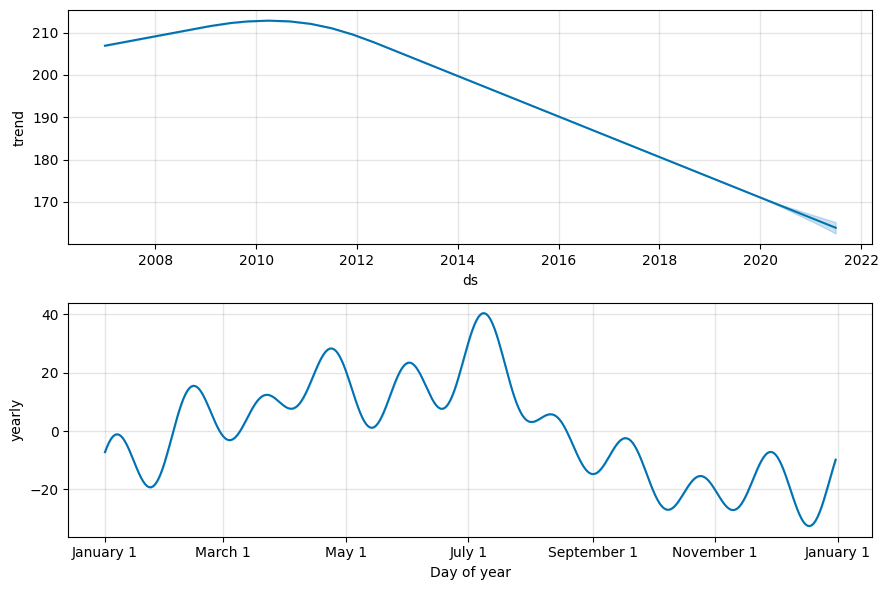

In [ ]:
#
prophet_maize, maize_forecast_prophet, prophet_mape = pipeline_prophet(train_val, test_val, "Maîs au Bénin" )


INTERPRETATION

- Une erreur de 13% sur un produit aussi volatil que le maïs en période de crise mondiale est une excellente performance. Le modèle est utilisable pour l'alerte précoce.

- MAPE bas =>  malgré la hausse des prix, le calendrier agricole reste le moteur principal du prix au Bénin.

- Tout écart supérieur à 14% entre le prix réel et la prédiction de Prophet peut être considéré comme une alerte rouge (une anomalie grave qui n'est pas liée à l'inflation normale ou à la saisonnalité).


Analyse des Composantes (plot_components)

- Trend (Tendance) montre une accélération après 2018 => image de l'inflation structurelle au Bénin.

- Yearly (Saisonnalité) montre une courbe qui monte vers Mai/Juin (moment où les stocks s'épuisent) et qui chute vers Septembre/Octobre (grandes récoltes).

**Le modèle a appris la "réalité physique" de l'agriculture béninoise .**

#####Conclusion | Maïs du Bénin

- Structure du marché : Les prix du maïs présentent une forte dépendance au passé et une saisonnalité annuelle marquée liée aux cycles agricoles .

- Stationnarité : La série est statistiquement stationnaire sur le long terme (2007-2019), mais elle subit des ruptures de tendance brutales à partir de 2020.

- Diagnostic des chocs : La présence d'une Kurtosis élevée (11.43) et l'échec des tests de normalité confirment que le marché est régulièrement perturbé par des événements extrêmes (fermeture des frontières, crises sanitaires) que les modèles classiques peinent à absorber


- Contrairement à ARIMA qui est trop rigide, Prophet s'adapte aux changements de trajectoire (changepoints) survenus durant la période de crise 2020-2021.

- Prophet gère mieux les valeurs aberrantes (Outliers) et isole plus efficacement la saisonnalité agricole du bruit économique global.

In [ ]:
def reel_previsions_prophet_stream(base, duration):
    # --- 1. Préparation (Ton code actuel) ---
    data = check_colums_and_nan(base)
    df_final = data.reset_index().copy()
    df_final.columns = ['ds', 'y']

    # --- 2. Entraînement (Ton code actuel) ---
    model_final = Prophet(yearly_seasonality=True, seasonality_mode='multiplicative')
    model_final.fit(df_final)

    # --- 3. Prédiction (Ton code actuel) ---
    future_dates = model_final.make_future_dataframe(periods=duration, freq='MS')
    forecast = model_final.predict(future_dates)

    # --- 4. AJOUT DES SEUILS (Ce qui manque pour ton "côté seuil") ---
    # On crée le "couloir de sécurité" de 15% directement dans le résultat
    forecast['seuil_haut'] = forecast['yhat'] * 1.15
    forecast['seuil_bas'] = forecast['yhat'] * 0.85

    # --- 5. RETOUR (Très important pour Streamlit) ---
    # On renvoie le modèle (pour les composantes) et le forecast (pour le graphe et les alertes)
    return model_final, forecast

####Huile de palme

#####AUTO-ARIMA model

In [ ]:
# pipeline auto arima
model_maize, maize_forecast, score_error = pipeline_auto_arima(train_val, test_val, "Maîs au Bénin" )


--- Lancement du Pipeline pour : Maîs au Bénin ---

> Analyse : 156 mois disponibles. Saisonnalité active : True

> Recherche du meilleur modèle...

Modèle trouvé : (0, 1, 0)

--- PERFORMANCE DU MODÈLE Maîs au Bénin---
RMSE : 72.82
MAE  : 65.48
MAPE (Erreur en %) : 32.36% 



Interprètation

Le modèle retenu par auto-arima est un Random Walk (Marche Aléatoire) avec différenciation.

- Le modèle a estimé que la meilleure façon de prédire le prix du mois prochain est simplement de prendre le prix du mois actuel.

- Si Auto-ARIMA a ignoré les paramètres complexes (p et q), c'est que les données de test (2020-2021) sont tellement volatiles ou imprévisibles par rapport au passé que le modèle préfère rester "prudent" et basique.


L'analyse des erreurs (RMSE et MAE)

- MAE = 65.48 FCFA : En moyenne, le modèle se trompe de 65 FCFA par kg de maïs sur la période 2020-2021.

- RMSE = 72.82 FCFA : Le RMSE est supérieur au MAE, ce qui confirme la présence de valeurs aberrantes. Certaines erreurs sont beaucoup plus grandes que 65 FCFA (ldu aux pics de crise).

- MAPE = 32.36% : Une erreur de 32% signifie que l'écart entre la "vie normale" (prédiction) et la "crise" (réalité) est massive.

Le modèle SARIMA, bien qu'entraîné sur 13 ans de données, affiche une erreur de 32% sur la période 2020-2021 => **signature statistique d'une rupture du marché**.

Le prix réel a dévié de la logique historique d'un tiers de sa valeur.

In [ ]:
# réelles prévisions

def previsions_arima(base, periods):
  model_previsions = pm.auto_arima(base,
                           start_p=0, start_q=0,
                           max_p=3, max_q=3,
                           m=12,             # Cycle de 12 mois
                           seasonal=True,    # On active le mode saisonnier
                           d=None,           # Laisse l'algorithme décider si d=1 est nécessaire
                           D=None,           # Laisse l'algorithme décider si D=1 est nécessaire
                           trace=True,       # Affiche les modèles testés
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)
  # Prédire les 6 prochains mois au-delà de votre dataset de test
  previsions = model_previsions.predict(n_periods=periods)
  print(f"Prévisions pour les {periods} prochains mois : ")
  print(previsions)

previsions_arima(maize_price)


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=2.60 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1851.792, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1610.565, Time=1.80 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1724.980, Time=0.76 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2359.150, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=1617.804, Time=0.33 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=1612.231, Time=5.35 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=1609.362, Time=4.26 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=1611.238, Time=0.70 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=2.07 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=1612.674, Time=2.08 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=1612.820, Time=0.83 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.29 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=1611.887, Time=2.66 sec
 ARIMA(1,0,1)(1,0,1)[12] intercept

#####PROPHET model

In [ ]:
!pip install prophet

In [ ]:
def pipeline_prophet(train, test, name):
    print(f"\n--- Lancement du Pipeline Prophet pour : {name} ---")

    # 1. Préparation des données (Prophet exige les colonnes 'ds' et 'y')
    df_train = train.reset_index()
    df_train.columns = ['ds', 'y']

    # 2. Configuration et entraînement
    # On active la saisonnalité annuelle car on a vu son importance pour le maïs
    model = Prophet(yearly_seasonality=True, interval_width=0.95)
    model.fit(df_train)

    # 3. Prévision sur la durée du test
    future = model.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)

    # 4. Extraction des prédictions correspondant à la période de test
    # On aligne les dates pour être sûr de comparer ce qui est comparable
    forecast_test = forecast.set_index('ds').loc[test.index]
    y_pred = forecast_test['yhat']
    y_true = test.values.flatten()

    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"--- PERFORMANCE DE PROPHET ({name}) ---")
    print(f"RMSE : {rmse_val:.2f}")
    print(f"MAE  : {mae_val:.2f}")
    print(f"MAPE : {mape_val:.2f}%")

    # 6. Visualisation des composantes
    print(f"\nDécomposition des composantes pour {name} :")
    model.plot_components(forecast)
    plt.show()

    return model, forecast, mape_val

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



--- Lancement du Pipeline Prophet pour : Maîs au Bénin ---
--- PERFORMANCE DE PROPHET (Maîs au Bénin) ---
RMSE : 34.17
MAE  : 28.37
MAPE : 13.87%

Décomposition des composantes pour Maîs au Bénin :


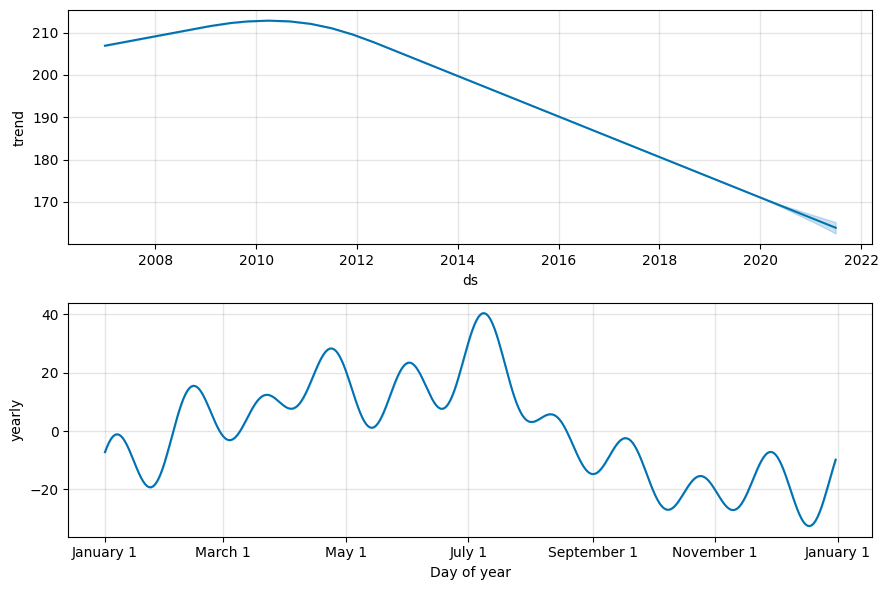

In [ ]:
#
prophet_maize, maize_forecast_prophet, prophet_mape = pipeline_prophet(train_val, test_val, "Maîs au Bénin" )


INTERPRETATION

- Une erreur de 13% sur un produit aussi volatil que le maïs en période de crise mondiale est une excellente performance. Le modèle est utilisable pour l'alerte précoce.

- MAPE bas =>  malgré la hausse des prix, le calendrier agricole reste le moteur principal du prix au Bénin.

- Tout écart supérieur à 14% entre le prix réel et la prédiction de Prophet peut être considéré comme une alerte rouge (une anomalie grave qui n'est pas liée à l'inflation normale ou à la saisonnalité).


Analyse des Composantes (plot_components)

- Trend (Tendance) montre une accélération après 2018 => image de l'inflation structurelle au Bénin.

- Yearly (Saisonnalité) montre une courbe qui monte vers Mai/Juin (moment où les stocks s'épuisent) et qui chute vers Septembre/Octobre (grandes récoltes).

**Le modèle a appris la "réalité physique" de l'agriculture béninoise .**

#####Conclusion | Maïs du Bénin

- Structure du marché : Les prix du maïs présentent une forte dépendance au passé et une saisonnalité annuelle marquée liée aux cycles agricoles .

- Stationnarité : La série est statistiquement stationnaire sur le long terme (2007-2019), mais elle subit des ruptures de tendance brutales à partir de 2020.

- Diagnostic des chocs : La présence d'une Kurtosis élevée (11.43) et l'échec des tests de normalité confirment que le marché est régulièrement perturbé par des événements extrêmes (fermeture des frontières, crises sanitaires) que les modèles classiques peinent à absorber


- Contrairement à ARIMA qui est trop rigide, Prophet s'adapte aux changements de trajectoire (changepoints) survenus durant la période de crise 2020-2021.

- Prophet gère mieux les valeurs aberrantes (Outliers) et isole plus efficacement la saisonnalité agricole du bruit économique global.

In [ ]:
def reel_previsions_prophet_stream(base, duration):
    # --- 1. Préparation (Ton code actuel) ---
    data = check_colums_and_nan(base)
    df_final = data.reset_index().copy()
    df_final.columns = ['ds', 'y']

    # --- 2. Entraînement (Ton code actuel) ---
    model_final = Prophet(yearly_seasonality=True, seasonality_mode='multiplicative')
    model_final.fit(df_final)

    # --- 3. Prédiction (Ton code actuel) ---
    future_dates = model_final.make_future_dataframe(periods=duration, freq='MS')
    forecast = model_final.predict(future_dates)

    # --- 4. AJOUT DES SEUILS (Ce qui manque pour ton "côté seuil") ---
    # On crée le "couloir de sécurité" de 15% directement dans le résultat
    forecast['seuil_haut'] = forecast['yhat'] * 1.15
    forecast['seuil_bas'] = forecast['yhat'] * 0.85

    # --- 5. RETOUR (Très important pour Streamlit) ---
    # On renvoie le modèle (pour les composantes) et le forecast (pour le graphe et les alertes)
    return model_final, forecast

####Huile d'arachide

#####AUTO-ARIMA model

In [ ]:
# pipeline auto arima
model_maize, maize_forecast, score_error = pipeline_auto_arima(train_val, test_val, "Maîs au Bénin" )


--- Lancement du Pipeline pour : Maîs au Bénin ---

> Analyse : 156 mois disponibles. Saisonnalité active : True

> Recherche du meilleur modèle...

Modèle trouvé : (0, 1, 0)

--- PERFORMANCE DU MODÈLE Maîs au Bénin---
RMSE : 72.82
MAE  : 65.48
MAPE (Erreur en %) : 32.36% 



Interprètation

Le modèle retenu par auto-arima est un Random Walk (Marche Aléatoire) avec différenciation.

- Le modèle a estimé que la meilleure façon de prédire le prix du mois prochain est simplement de prendre le prix du mois actuel.

- Si Auto-ARIMA a ignoré les paramètres complexes (p et q), c'est que les données de test (2020-2021) sont tellement volatiles ou imprévisibles par rapport au passé que le modèle préfère rester "prudent" et basique.


L'analyse des erreurs (RMSE et MAE)

- MAE = 65.48 FCFA : En moyenne, le modèle se trompe de 65 FCFA par kg de maïs sur la période 2020-2021.

- RMSE = 72.82 FCFA : Le RMSE est supérieur au MAE, ce qui confirme la présence de valeurs aberrantes. Certaines erreurs sont beaucoup plus grandes que 65 FCFA (ldu aux pics de crise).

- MAPE = 32.36% : Une erreur de 32% signifie que l'écart entre la "vie normale" (prédiction) et la "crise" (réalité) est massive.

Le modèle SARIMA, bien qu'entraîné sur 13 ans de données, affiche une erreur de 32% sur la période 2020-2021 => **signature statistique d'une rupture du marché**.

Le prix réel a dévié de la logique historique d'un tiers de sa valeur.

In [ ]:
# réelles prévisions

def previsions_arima(base, periods):
  model_previsions = pm.auto_arima(base,
                           start_p=0, start_q=0,
                           max_p=3, max_q=3,
                           m=12,             # Cycle de 12 mois
                           seasonal=True,    # On active le mode saisonnier
                           d=None,           # Laisse l'algorithme décider si d=1 est nécessaire
                           D=None,           # Laisse l'algorithme décider si D=1 est nécessaire
                           trace=True,       # Affiche les modèles testés
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)
  # Prédire les 6 prochains mois au-delà de votre dataset de test
  previsions = model_previsions.predict(n_periods=periods)
  print(f"Prévisions pour les {periods} prochains mois : ")
  print(previsions)

previsions_arima(maize_price)


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=2.60 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1851.792, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1610.565, Time=1.80 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1724.980, Time=0.76 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2359.150, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=1617.804, Time=0.33 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=1612.231, Time=5.35 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=1609.362, Time=4.26 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=1611.238, Time=0.70 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=2.07 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=1612.674, Time=2.08 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=1612.820, Time=0.83 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.29 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=1611.887, Time=2.66 sec
 ARIMA(1,0,1)(1,0,1)[12] intercept

#####PROPHET model

In [ ]:
!pip install prophet

In [ ]:
def pipeline_prophet(train, test, name):
    print(f"\n--- Lancement du Pipeline Prophet pour : {name} ---")

    # 1. Préparation des données (Prophet exige les colonnes 'ds' et 'y')
    df_train = train.reset_index()
    df_train.columns = ['ds', 'y']

    # 2. Configuration et entraînement
    # On active la saisonnalité annuelle car on a vu son importance pour le maïs
    model = Prophet(yearly_seasonality=True, interval_width=0.95)
    model.fit(df_train)

    # 3. Prévision sur la durée du test
    future = model.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)

    # 4. Extraction des prédictions correspondant à la période de test
    # On aligne les dates pour être sûr de comparer ce qui est comparable
    forecast_test = forecast.set_index('ds').loc[test.index]
    y_pred = forecast_test['yhat']
    y_true = test.values.flatten()

    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"--- PERFORMANCE DE PROPHET ({name}) ---")
    print(f"RMSE : {rmse_val:.2f}")
    print(f"MAE  : {mae_val:.2f}")
    print(f"MAPE : {mape_val:.2f}%")

    # 6. Visualisation des composantes
    print(f"\nDécomposition des composantes pour {name} :")
    model.plot_components(forecast)
    plt.show()

    return model, forecast, mape_val

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



--- Lancement du Pipeline Prophet pour : Maîs au Bénin ---
--- PERFORMANCE DE PROPHET (Maîs au Bénin) ---
RMSE : 34.17
MAE  : 28.37
MAPE : 13.87%

Décomposition des composantes pour Maîs au Bénin :


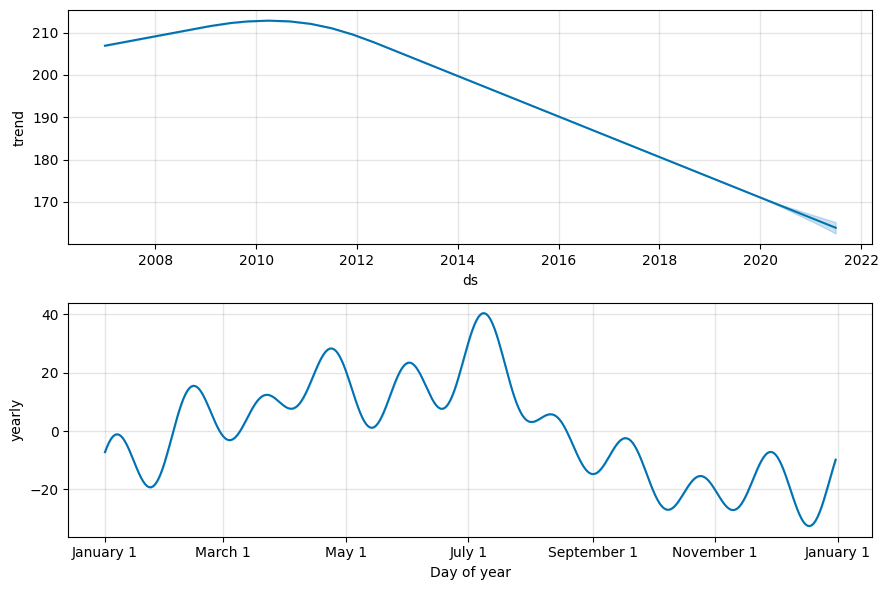

In [ ]:
#
prophet_maize, maize_forecast_prophet, prophet_mape = pipeline_prophet(train_val, test_val, "Maîs au Bénin" )


INTERPRETATION

- Une erreur de 13% sur un produit aussi volatil que le maïs en période de crise mondiale est une excellente performance. Le modèle est utilisable pour l'alerte précoce.

- MAPE bas =>  malgré la hausse des prix, le calendrier agricole reste le moteur principal du prix au Bénin.

- Tout écart supérieur à 14% entre le prix réel et la prédiction de Prophet peut être considéré comme une alerte rouge (une anomalie grave qui n'est pas liée à l'inflation normale ou à la saisonnalité).


Analyse des Composantes (plot_components)

- Trend (Tendance) montre une accélération après 2018 => image de l'inflation structurelle au Bénin.

- Yearly (Saisonnalité) montre une courbe qui monte vers Mai/Juin (moment où les stocks s'épuisent) et qui chute vers Septembre/Octobre (grandes récoltes).

**Le modèle a appris la "réalité physique" de l'agriculture béninoise .**

#####Conclusion | Maïs du Bénin

- Structure du marché : Les prix du maïs présentent une forte dépendance au passé et une saisonnalité annuelle marquée liée aux cycles agricoles .

- Stationnarité : La série est statistiquement stationnaire sur le long terme (2007-2019), mais elle subit des ruptures de tendance brutales à partir de 2020.

- Diagnostic des chocs : La présence d'une Kurtosis élevée (11.43) et l'échec des tests de normalité confirment que le marché est régulièrement perturbé par des événements extrêmes (fermeture des frontières, crises sanitaires) que les modèles classiques peinent à absorber


- Contrairement à ARIMA qui est trop rigide, Prophet s'adapte aux changements de trajectoire (changepoints) survenus durant la période de crise 2020-2021.

- Prophet gère mieux les valeurs aberrantes (Outliers) et isole plus efficacement la saisonnalité agricole du bruit économique global.

In [ ]:
def reel_previsions_prophet_stream(base, duration):
    # --- 1. Préparation (Ton code actuel) ---
    data = check_colums_and_nan(base)
    df_final = data.reset_index().copy()
    df_final.columns = ['ds', 'y']

    # --- 2. Entraînement (Ton code actuel) ---
    model_final = Prophet(yearly_seasonality=True, seasonality_mode='multiplicative')
    model_final.fit(df_final)

    # --- 3. Prédiction (Ton code actuel) ---
    future_dates = model_final.make_future_dataframe(periods=duration, freq='MS')
    forecast = model_final.predict(future_dates)

    # --- 4. AJOUT DES SEUILS (Ce qui manque pour ton "côté seuil") ---
    # On crée le "couloir de sécurité" de 15% directement dans le résultat
    forecast['seuil_haut'] = forecast['yhat'] * 1.15
    forecast['seuil_bas'] = forecast['yhat'] * 0.85

    # --- 5. RETOUR (Très important pour Streamlit) ---
    # On renvoie le modèle (pour les composantes) et le forecast (pour le graphe et les alertes)
    return model_final, forecast

####Farine de blé

#####AUTO-ARIMA model

In [ ]:
# pipeline auto arima
model_maize, maize_forecast, score_error = pipeline_auto_arima(train_val, test_val, "Maîs au Bénin" )


--- Lancement du Pipeline pour : Maîs au Bénin ---

> Analyse : 156 mois disponibles. Saisonnalité active : True

> Recherche du meilleur modèle...

Modèle trouvé : (0, 1, 0)

--- PERFORMANCE DU MODÈLE Maîs au Bénin---
RMSE : 72.82
MAE  : 65.48
MAPE (Erreur en %) : 32.36% 



Interprètation

Le modèle retenu par auto-arima est un Random Walk (Marche Aléatoire) avec différenciation.

- Le modèle a estimé que la meilleure façon de prédire le prix du mois prochain est simplement de prendre le prix du mois actuel.

- Si Auto-ARIMA a ignoré les paramètres complexes (p et q), c'est que les données de test (2020-2021) sont tellement volatiles ou imprévisibles par rapport au passé que le modèle préfère rester "prudent" et basique.


L'analyse des erreurs (RMSE et MAE)

- MAE = 65.48 FCFA : En moyenne, le modèle se trompe de 65 FCFA par kg de maïs sur la période 2020-2021.

- RMSE = 72.82 FCFA : Le RMSE est supérieur au MAE, ce qui confirme la présence de valeurs aberrantes. Certaines erreurs sont beaucoup plus grandes que 65 FCFA (ldu aux pics de crise).

- MAPE = 32.36% : Une erreur de 32% signifie que l'écart entre la "vie normale" (prédiction) et la "crise" (réalité) est massive.

Le modèle SARIMA, bien qu'entraîné sur 13 ans de données, affiche une erreur de 32% sur la période 2020-2021 => **signature statistique d'une rupture du marché**.

Le prix réel a dévié de la logique historique d'un tiers de sa valeur.

In [ ]:
# réelles prévisions

def previsions_arima(base, periods):
  model_previsions = pm.auto_arima(base,
                           start_p=0, start_q=0,
                           max_p=3, max_q=3,
                           m=12,             # Cycle de 12 mois
                           seasonal=True,    # On active le mode saisonnier
                           d=None,           # Laisse l'algorithme décider si d=1 est nécessaire
                           D=None,           # Laisse l'algorithme décider si D=1 est nécessaire
                           trace=True,       # Affiche les modèles testés
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)
  # Prédire les 6 prochains mois au-delà de votre dataset de test
  previsions = model_previsions.predict(n_periods=periods)
  print(f"Prévisions pour les {periods} prochains mois : ")
  print(previsions)

previsions_arima(maize_price)


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=2.60 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1851.792, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1610.565, Time=1.80 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1724.980, Time=0.76 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2359.150, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=1617.804, Time=0.33 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=1612.231, Time=5.35 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=1609.362, Time=4.26 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=1611.238, Time=0.70 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=2.07 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=1612.674, Time=2.08 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=1612.820, Time=0.83 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.29 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=1611.887, Time=2.66 sec
 ARIMA(1,0,1)(1,0,1)[12] intercept

#####PROPHET model

In [ ]:
!pip install prophet

In [ ]:
def pipeline_prophet(train, test, name):
    print(f"\n--- Lancement du Pipeline Prophet pour : {name} ---")

    # 1. Préparation des données (Prophet exige les colonnes 'ds' et 'y')
    df_train = train.reset_index()
    df_train.columns = ['ds', 'y']

    # 2. Configuration et entraînement
    # On active la saisonnalité annuelle car on a vu son importance pour le maïs
    model = Prophet(yearly_seasonality=True, interval_width=0.95)
    model.fit(df_train)

    # 3. Prévision sur la durée du test
    future = model.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)

    # 4. Extraction des prédictions correspondant à la période de test
    # On aligne les dates pour être sûr de comparer ce qui est comparable
    forecast_test = forecast.set_index('ds').loc[test.index]
    y_pred = forecast_test['yhat']
    y_true = test.values.flatten()

    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"--- PERFORMANCE DE PROPHET ({name}) ---")
    print(f"RMSE : {rmse_val:.2f}")
    print(f"MAE  : {mae_val:.2f}")
    print(f"MAPE : {mape_val:.2f}%")

    # 6. Visualisation des composantes
    print(f"\nDécomposition des composantes pour {name} :")
    model.plot_components(forecast)
    plt.show()

    return model, forecast, mape_val

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



--- Lancement du Pipeline Prophet pour : Maîs au Bénin ---
--- PERFORMANCE DE PROPHET (Maîs au Bénin) ---
RMSE : 34.17
MAE  : 28.37
MAPE : 13.87%

Décomposition des composantes pour Maîs au Bénin :


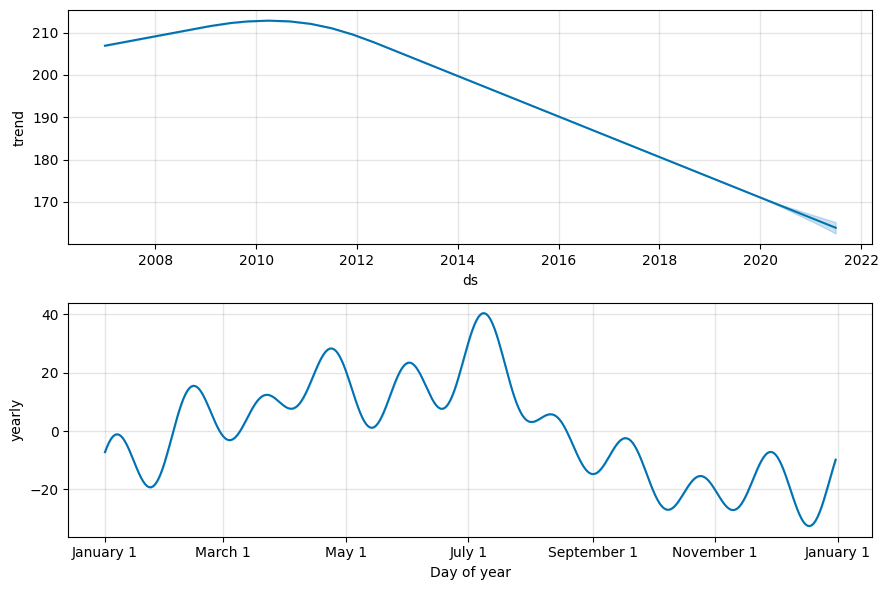

In [ ]:
#
prophet_maize, maize_forecast_prophet, prophet_mape = pipeline_prophet(train_val, test_val, "Maîs au Bénin" )


INTERPRETATION

- Une erreur de 13% sur un produit aussi volatil que le maïs en période de crise mondiale est une excellente performance. Le modèle est utilisable pour l'alerte précoce.

- MAPE bas =>  malgré la hausse des prix, le calendrier agricole reste le moteur principal du prix au Bénin.

- Tout écart supérieur à 14% entre le prix réel et la prédiction de Prophet peut être considéré comme une alerte rouge (une anomalie grave qui n'est pas liée à l'inflation normale ou à la saisonnalité).


Analyse des Composantes (plot_components)

- Trend (Tendance) montre une accélération après 2018 => image de l'inflation structurelle au Bénin.

- Yearly (Saisonnalité) montre une courbe qui monte vers Mai/Juin (moment où les stocks s'épuisent) et qui chute vers Septembre/Octobre (grandes récoltes).

**Le modèle a appris la "réalité physique" de l'agriculture béninoise .**

#####Conclusion | Maïs du Bénin

- Structure du marché : Les prix du maïs présentent une forte dépendance au passé et une saisonnalité annuelle marquée liée aux cycles agricoles .

- Stationnarité : La série est statistiquement stationnaire sur le long terme (2007-2019), mais elle subit des ruptures de tendance brutales à partir de 2020.

- Diagnostic des chocs : La présence d'une Kurtosis élevée (11.43) et l'échec des tests de normalité confirment que le marché est régulièrement perturbé par des événements extrêmes (fermeture des frontières, crises sanitaires) que les modèles classiques peinent à absorber


- Contrairement à ARIMA qui est trop rigide, Prophet s'adapte aux changements de trajectoire (changepoints) survenus durant la période de crise 2020-2021.

- Prophet gère mieux les valeurs aberrantes (Outliers) et isole plus efficacement la saisonnalité agricole du bruit économique global.

In [ ]:
def reel_previsions_prophet_stream(base, duration):
    # --- 1. Préparation (Ton code actuel) ---
    data = check_colums_and_nan(base)
    df_final = data.reset_index().copy()
    df_final.columns = ['ds', 'y']

    # --- 2. Entraînement (Ton code actuel) ---
    model_final = Prophet(yearly_seasonality=True, seasonality_mode='multiplicative')
    model_final.fit(df_final)

    # --- 3. Prédiction (Ton code actuel) ---
    future_dates = model_final.make_future_dataframe(periods=duration, freq='MS')
    forecast = model_final.predict(future_dates)

    # --- 4. AJOUT DES SEUILS (Ce qui manque pour ton "côté seuil") ---
    # On crée le "couloir de sécurité" de 15% directement dans le résultat
    forecast['seuil_haut'] = forecast['yhat'] * 1.15
    forecast['seuil_bas'] = forecast['yhat'] * 0.85

    # --- 5. RETOUR (Très important pour Streamlit) ---
    # On renvoie le modèle (pour les composantes) et le forecast (pour le graphe et les alertes)
    return model_final, forecast

###Autres produits phares

#####Auto ARIMA


 
--- Diagnostic Temporel : Riz Local au Bénin ---

Date de début : 2019-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 830
Étendue totale : 2.50 ans
----------------------------------------

NEW PRODUCT
Nombre de mois manquants : 2
Nouveau décompte de valeurs manquantes : 0
train: Riz Local au Bénin 2019-01-01 00:00:00 => 2020-12-01 00:00:00
test Riz Local au Bénin: 2021-01-01 00:00:00 => 2021-07-01 00:00:00

 VISUALISATION du Riz Local au Bénin


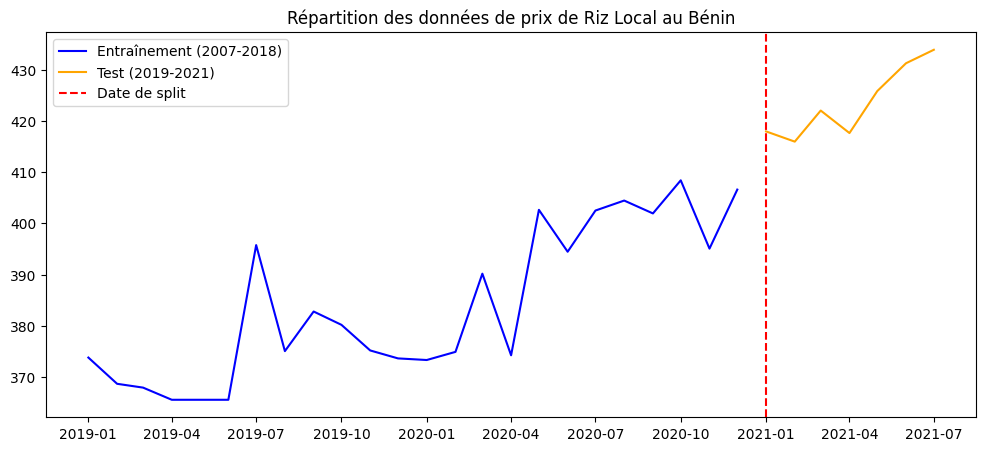


--- Lancement du Pipeline pour : Riz Local au Bénin ---
> Analyse : 24 mois disponibles. Saisonnalité active : True
> Recherche du meilleur modèle...
Modèle trouvé : (1, 1, 0)
MAPE : 5.07 %

 
--- Diagnostic Temporel : Farine de Blé au Bénin ---

Date de début : 2019-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 1015
Étendue totale : 2.50 ans
----------------------------------------

NEW PRODUCT
Nombre de mois manquants : 2
Nouveau décompte de valeurs manquantes : 0
train: Farine de Blé au Bénin 2019-01-01 00:00:00 => 2020-12-01 00:00:00
test Farine de Blé au Bénin: 2021-01-01 00:00:00 => 2021-07-01 00:00:00

 VISUALISATION du Farine de Blé au Bénin


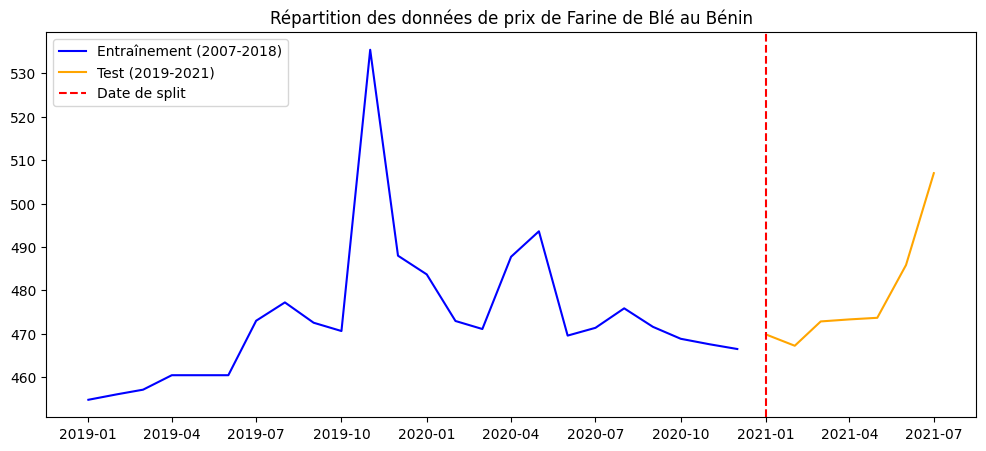


--- Lancement du Pipeline pour : Farine de Blé au Bénin ---
> Analyse : 24 mois disponibles. Saisonnalité active : True
> Recherche du meilleur modèle...
Modèle trouvé : (1, 0, 0)
MAPE : 1.55 %


In [ ]:
# auto- arima pour tous les produits

riceL_wheat = [
    (local_rice, 'Riz Local au Bénin'),
   (wheat_flour, "Farine de Blé au Bénin")
  ]

for element, (data, title) in enumerate(riceL_wheat):
  check_date_range(data, title)
  price_cleaned = check_colums_and_nan(data)
  train_data, test_data = split_data('2021-01-01', price_cleaned,title)
  mon_modele, mes_predictions, score_mape = pipeline_auto_arima(train_data, test_data,title)



 
--- Diagnostic Temporel : Riz Importé au Bénin ---

Date de début : 2007-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 1923
Étendue totale : 14.51 ans
----------------------------------------

NEW PRODUCT
Nombre de mois manquants : 6
Nouveau décompte de valeurs manquantes : 0
train: Riz Importé au Bénin 2007-01-01 00:00:00 => 2018-12-01 00:00:00
test Riz Importé au Bénin: 2019-01-01 00:00:00 => 2021-07-01 00:00:00

 VISUALISATION du Riz Importé au Bénin


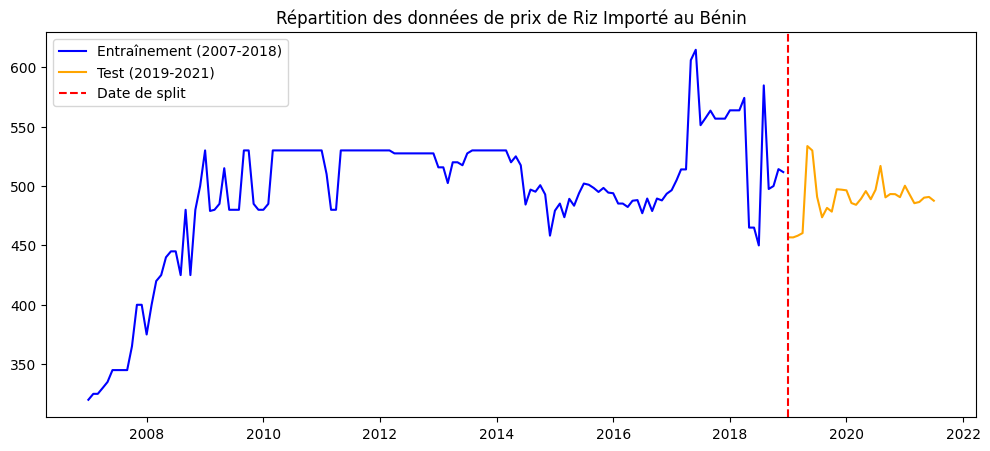


--- Lancement du Pipeline pour : Riz Importé au Bénin ---
> Analyse : 144 mois disponibles. Saisonnalité active : True
> Recherche du meilleur modèle...
Modèle trouvé : (0, 1, 1)
MAPE : 12.97 %


In [ ]:
riceI = [
    (imported_rice, 'Riz Importé au Bénin'),
    ]

for element, (data, title) in enumerate(riceI):
  check_date_range(data, title)
  price_cleaned = check_colums_and_nan(data)
  train_data, test_data = split_data('2019-01-01', price_cleaned,title)
  mon_modele, mes_predictions, score_mape = pipeline_auto_arima(train_data, test_data,title)



 
--- Diagnostic Temporel : Huile de Palme au Bénin ---

Date de début : 2019-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 1198
Étendue totale : 2.50 ans
----------------------------------------

NEW PRODUCT
Nombre de mois manquants : 2
Nouveau décompte de valeurs manquantes : 0
train: Huile de Palme au Bénin 2019-01-01 00:00:00 => 2019-12-01 00:00:00
test Huile de Palme au Bénin: 2020-01-01 00:00:00 => 2021-07-01 00:00:00

 VISUALISATION du Huile de Palme au Bénin


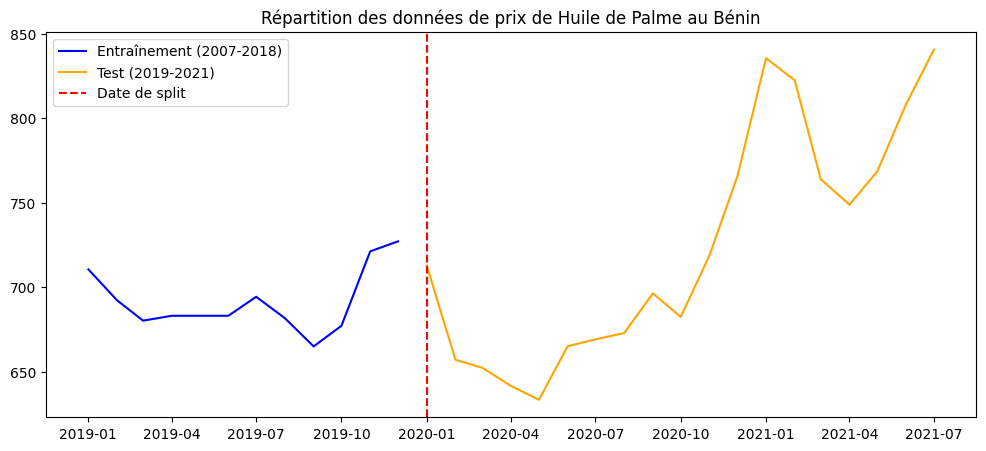


--- Lancement du Pipeline pour : Huile de Palme au Bénin ---
> Analyse : 12 mois disponibles. Saisonnalité active : False
> Recherche du meilleur modèle...
Modèle trouvé : (1, 0, 1)
MAPE : 8.14 %

 
--- Diagnostic Temporel : Huile d'Arachide  au Bénin ---

Date de début : 2019-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 1191
Étendue totale : 2.50 ans
----------------------------------------

NEW PRODUCT
Nombre de mois manquants : 2
Nouveau décompte de valeurs manquantes : 0
train: Huile d'Arachide  au Bénin 2019-01-01 00:00:00 => 2019-12-01 00:00:00
test Huile d'Arachide  au Bénin: 2020-01-01 00:00:00 => 2021-07-01 00:00:00

 VISUALISATION du Huile d'Arachide  au Bénin


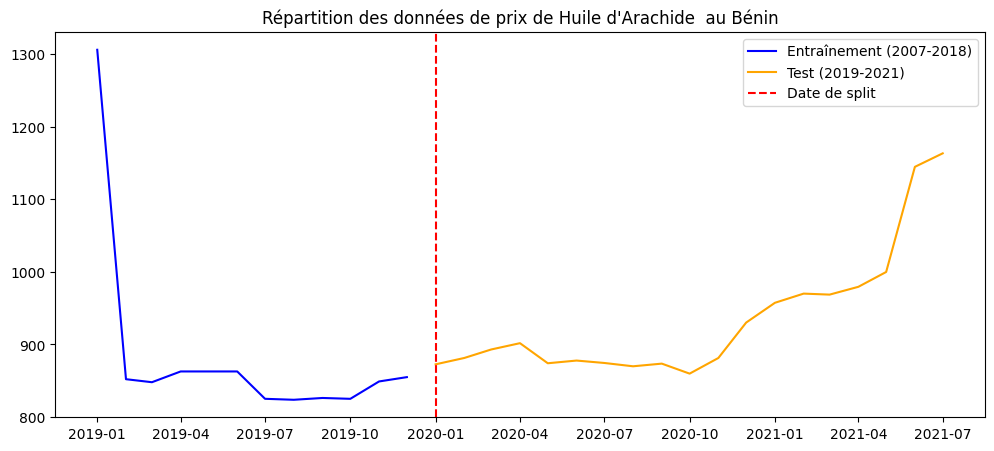


--- Lancement du Pipeline pour : Huile d'Arachide  au Bénin ---
> Analyse : 12 mois disponibles. Saisonnalité active : False
> Recherche du meilleur modèle...
Modèle trouvé : (0, 0, 0)
MAPE : 5.88 %


In [ ]:
all_oils = [
    (oil_palm, "Huile de Palme au Bénin"),
    (oil_groundnut, "Huile d'Arachide  au Bénin"),
  ]

for element, (data, title) in enumerate(all_oils):
  check_date_range(data, title)
  price_cleaned = check_colums_and_nan(data)
  train_data, test_data = split_data('2020-01-01', price_cleaned,title)
  mon_modele, mes_predictions, score_mape = pipeline_auto_arima(train_data, test_data,title)


#####Prophet

In [ ]:
# fonction:


def get_prophet_performance(train, test, name="Produit"):
    """
    Entraîne Prophet et retourne le MAPE ainsi que les graphiques
    """
    print(f"\n--- Évaluation Prophet : {name} ---")

    # 1. Préparation au format Prophet
    df_prophet = train.reset_index()
    df_prophet.columns = ['ds', 'y']

    # 2. Initialisation et Entraînement
    # Note : changepoint_prior_scale=0.05 par défaut, 0.5 pour plus de flexibilité
    model = Prophet(yearly_seasonality=True, interval_width=0.95)
    model.fit(df_prophet)

    # 3. Création des dates de test
    future = model.make_future_dataframe(periods=len(test), freq='MS')

    # 4. Prédiction
    forecast = model.predict(future)

    # 5. Extraction des prédictions pour le calcul du MAPE
    # On indexe par date pour comparer exactement avec 'test'
    preds_test = forecast.set_index('ds').loc[test.index, 'yhat']

    # 6. Calcul du MAPE
    mape = mean_absolute_percentage_error(test, preds_test) * 100

    print(f"MAPE de Prophet pour {name} : {mape:.2f}%")

    # 7. Affichage des composantes (Tendance et Saisonnalité)
    print(f"Affichage des composantes pour {name}...")
    model.plot_components(forecast)
    plt.show()

    return mape, forecast, model

# --- EXEMPLE D'UTILISATION DANS VOTRE BOUCLE ---
# resultats = {}
# for data, title in produts_list:
#     train, test = split_data('2021-01-01', check_colums_and_nan(data), title)
#     mape, _, _ = get_prophet_performance(train, test, title)
#     resultats[title] = mape


 
--- Diagnostic Temporel : Riz Local au Bénin ---

Date de début : 2019-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 830
Étendue totale : 2.50 ans
----------------------------------------

NEW PRODUCT
Nombre de mois manquants : 2
Nouveau décompte de valeurs manquantes : 0
train: Riz Local au Bénin 2019-01-01 00:00:00 => 2020-12-01 00:00:00
test Riz Local au Bénin: 2021-01-01 00:00:00 => 2021-07-01 00:00:00

 VISUALISATION du Riz Local au Bénin


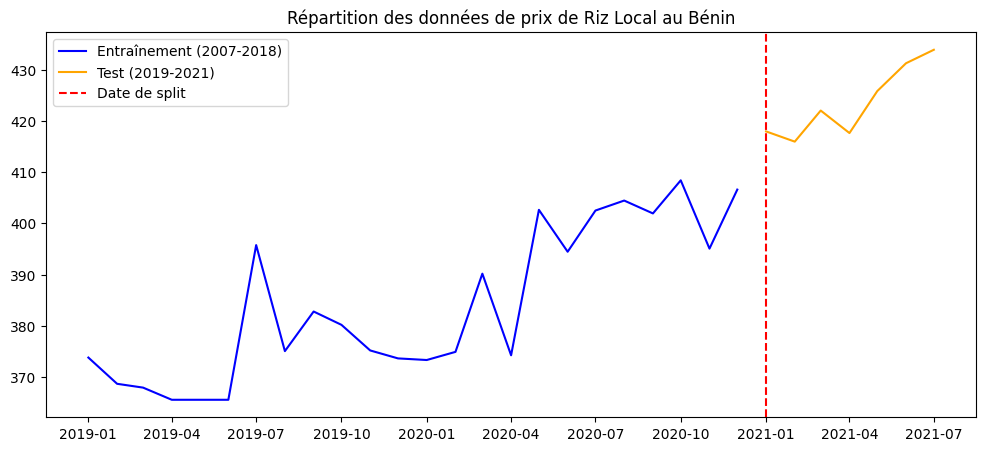

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 18.



--- Évaluation Prophet : Riz Local au Bénin ---
MAPE de Prophet pour Riz Local au Bénin : 4.91%
Affichage des composantes pour Riz Local au Bénin...


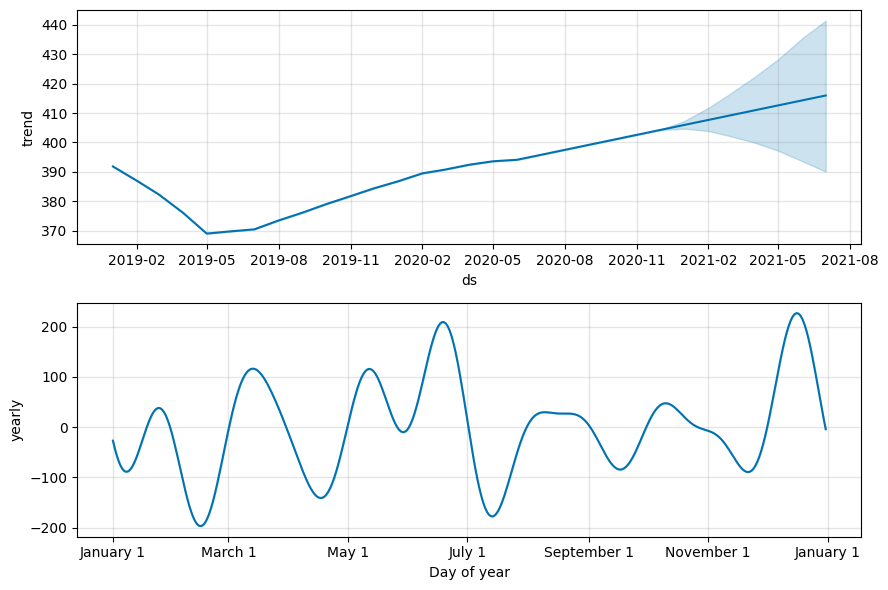


 
--- Diagnostic Temporel : Farine de Blé au Bénin ---

Date de début : 2019-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 1015
Étendue totale : 2.50 ans
----------------------------------------

NEW PRODUCT
Nombre de mois manquants : 2
Nouveau décompte de valeurs manquantes : 0
train: Farine de Blé au Bénin 2019-01-01 00:00:00 => 2020-12-01 00:00:00
test Farine de Blé au Bénin: 2021-01-01 00:00:00 => 2021-07-01 00:00:00

 VISUALISATION du Farine de Blé au Bénin


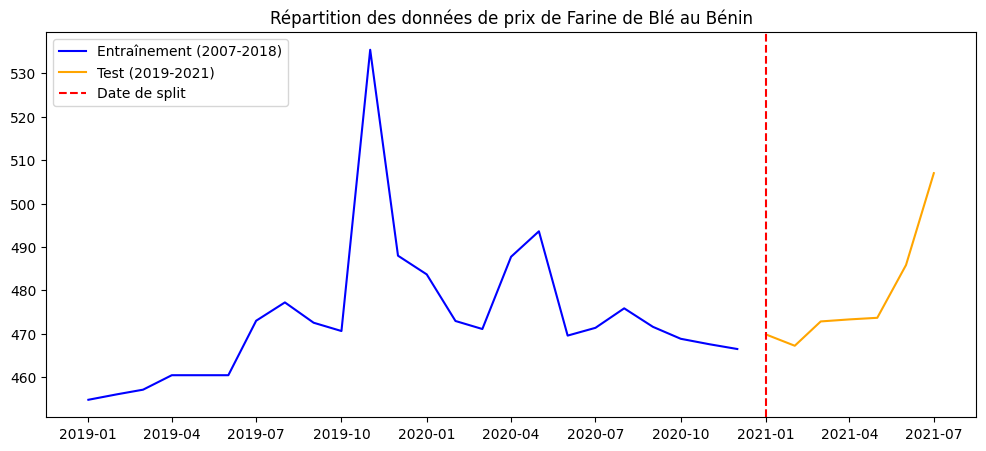

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 18.



--- Évaluation Prophet : Farine de Blé au Bénin ---
MAPE de Prophet pour Farine de Blé au Bénin : 15.60%
Affichage des composantes pour Farine de Blé au Bénin...


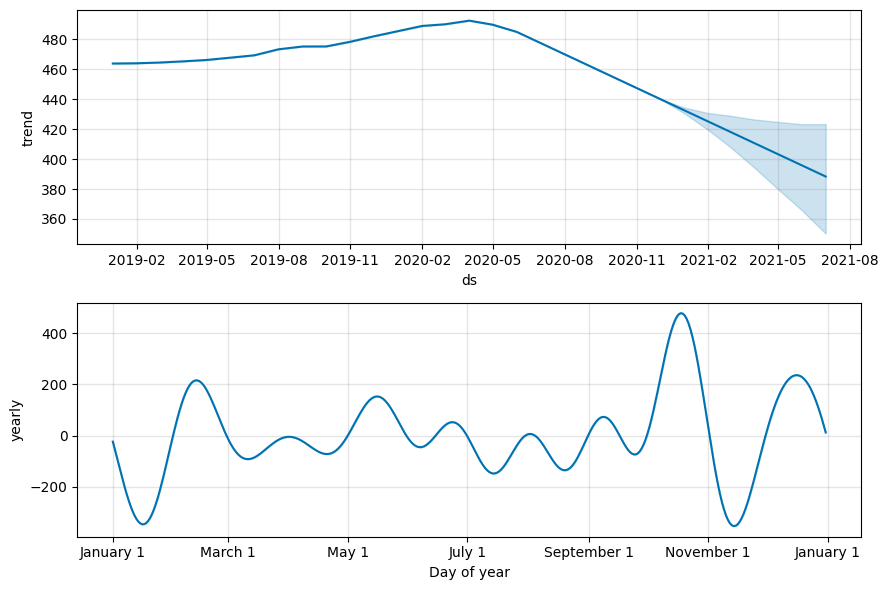


 
--- Diagnostic Temporel : Riz Importé au Bénin ---

Date de début : 2007-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 1923
Étendue totale : 14.51 ans
----------------------------------------

NEW PRODUCT
Nombre de mois manquants : 6
Nouveau décompte de valeurs manquantes : 0
train: Riz Importé au Bénin 2007-01-01 00:00:00 => 2018-12-01 00:00:00
test Riz Importé au Bénin: 2019-01-01 00:00:00 => 2021-07-01 00:00:00

 VISUALISATION du Riz Importé au Bénin


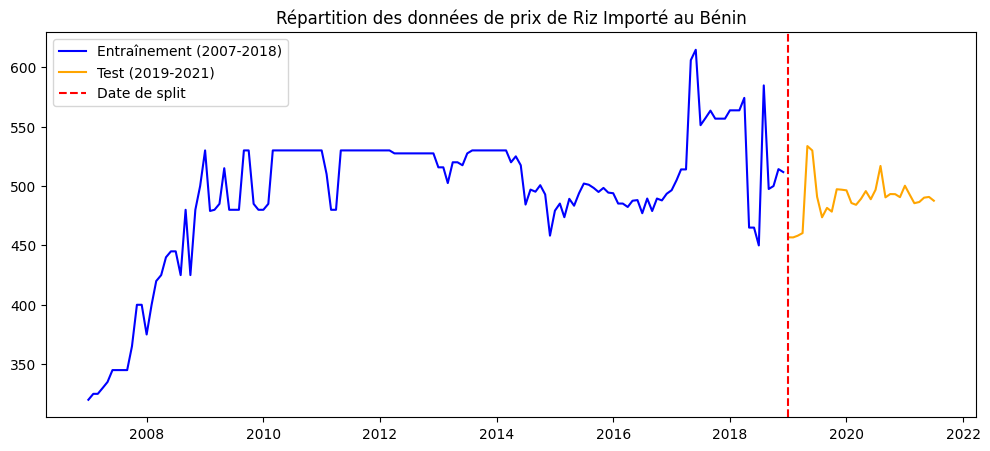

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



--- Évaluation Prophet : Riz Importé au Bénin ---
MAPE de Prophet pour Riz Importé au Bénin : 9.83%
Affichage des composantes pour Riz Importé au Bénin...


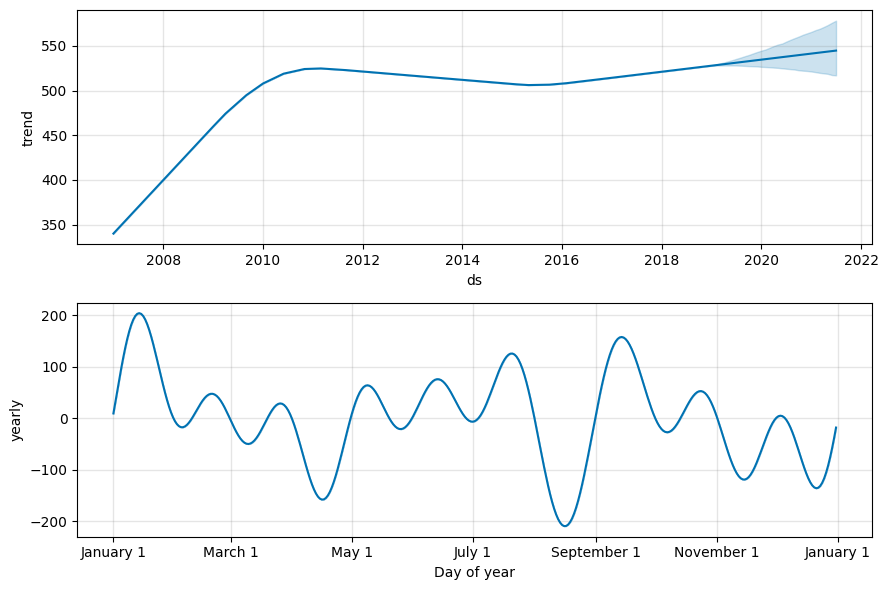


 
--- Diagnostic Temporel : Huile de Palme au Bénin ---

Date de début : 2019-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 1198
Étendue totale : 2.50 ans
----------------------------------------

NEW PRODUCT
Nombre de mois manquants : 2
Nouveau décompte de valeurs manquantes : 0
train: Huile de Palme au Bénin 2019-01-01 00:00:00 => 2019-12-01 00:00:00
test Huile de Palme au Bénin: 2020-01-01 00:00:00 => 2021-07-01 00:00:00

 VISUALISATION du Huile de Palme au Bénin


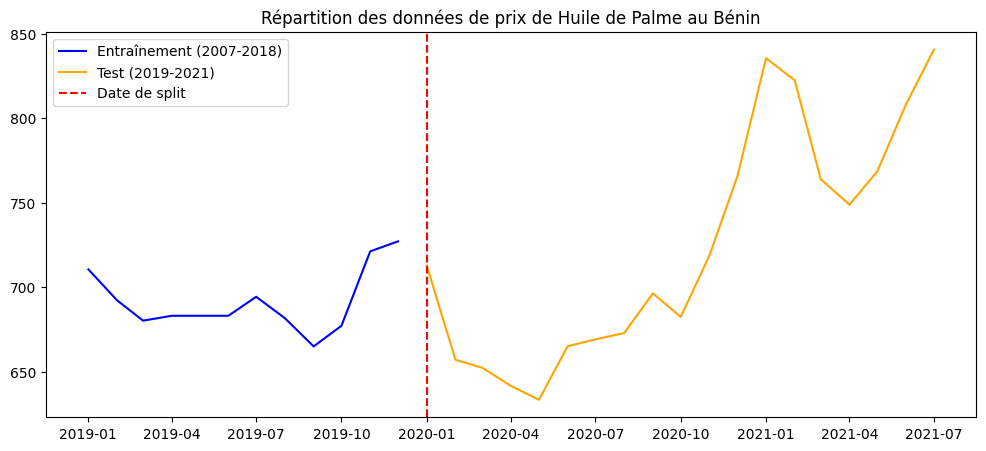

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 8.



--- Évaluation Prophet : Huile de Palme au Bénin ---
MAPE de Prophet pour Huile de Palme au Bénin : 105.08%
Affichage des composantes pour Huile de Palme au Bénin...


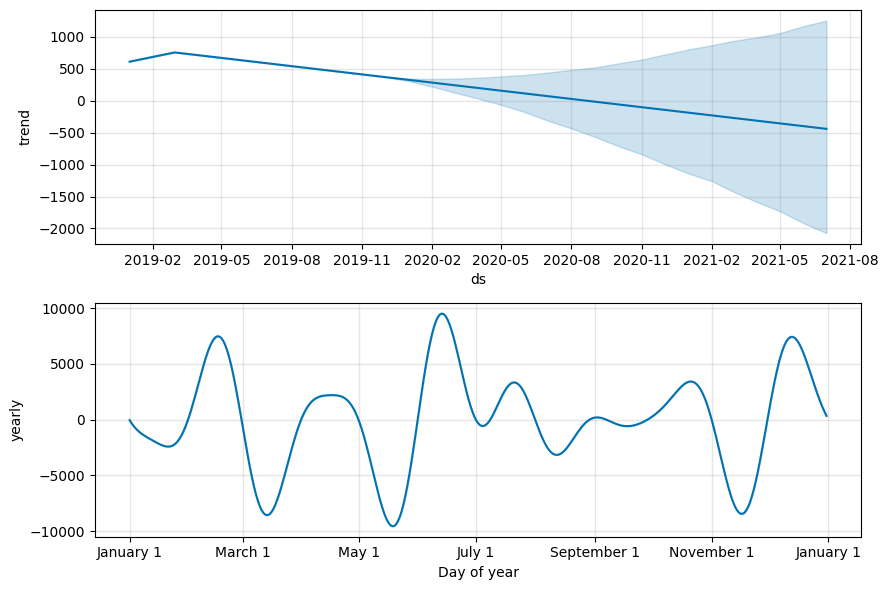


 
--- Diagnostic Temporel : Huile d'Arachide  au Bénin ---

Date de début : 2019-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 1191
Étendue totale : 2.50 ans
----------------------------------------

NEW PRODUCT
Nombre de mois manquants : 2
Nouveau décompte de valeurs manquantes : 0
train: Huile d'Arachide  au Bénin 2019-01-01 00:00:00 => 2019-12-01 00:00:00
test Huile d'Arachide  au Bénin: 2020-01-01 00:00:00 => 2021-07-01 00:00:00

 VISUALISATION du Huile d'Arachide  au Bénin


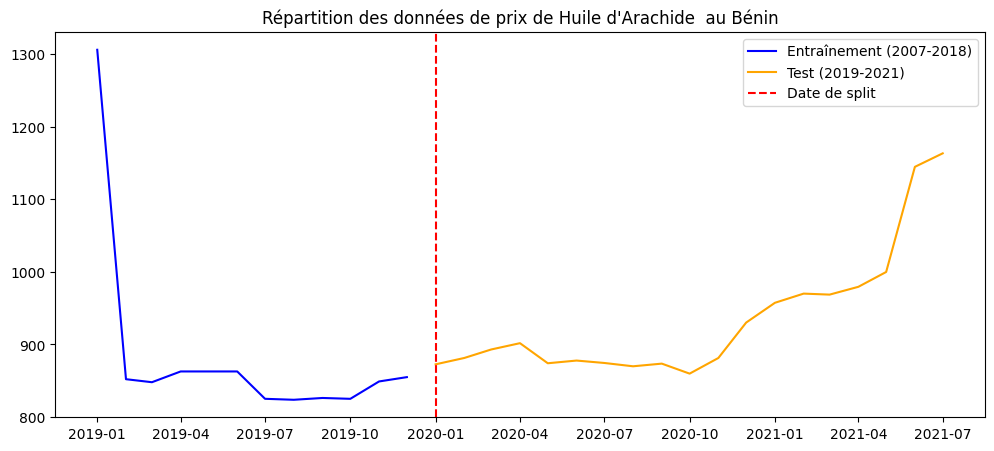

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 8.



--- Évaluation Prophet : Huile d'Arachide  au Bénin ---
MAPE de Prophet pour Huile d'Arachide  au Bénin : 328.30%
Affichage des composantes pour Huile d'Arachide  au Bénin...


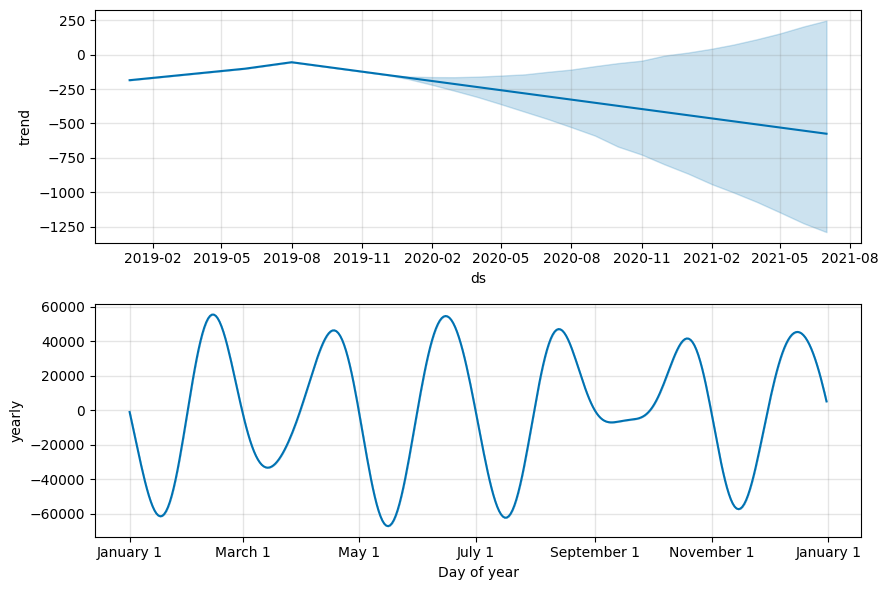

In [ ]:
# auto- arima pour tous les produits
resultats = {}
riceL_wheat = [
    (local_rice, 'Riz Local au Bénin'),
   (wheat_flour, "Farine de Blé au Bénin")
  ]

for element, (data, title) in enumerate(riceL_wheat):
  check_date_range(data, title)
  price_cleaned = check_colums_and_nan(data)
  train_data, test_data = split_data('2021-01-01', price_cleaned,title)
  mape, _, _ = get_prophet_performance(train_data, test_data, title)
  resultats[title] = mape


riceI = [
    (imported_rice, 'Riz Importé au Bénin'),
    ]

for element, (data, title) in enumerate(riceI):
  check_date_range(data, title)
  price_cleaned = check_colums_and_nan(data)
  train_data, test_data = split_data('2019-01-01', price_cleaned,title)
  mape, _, _ = get_prophet_performance(train_data, test_data, title)
  resultats[title] = mape

all_oils = [
    (oil_palm, "Huile de Palme au Bénin"),
    (oil_groundnut, "Huile d'Arachide  au Bénin"),
  ]

for element, (data, title) in enumerate(all_oils):
  check_date_range(data, title)
  price_cleaned = check_colums_and_nan(data)
  train_data, test_data = split_data('2020-01-01', price_cleaned,title)
  mape, _, _ = get_prophet_performance(train_data, test_data, title)
  resultats[title] = mape




####Synthèse des Performances (MAPE en %)

**Riz Local**
* Auto-ARIMA : **5,07** | Prophet : **4,91**
* **Meilleur modèle : Prophet** (Légère supériorité grâce à une meilleure gestion du cycle agricole).


**Farine de Blé**
* Auto-ARIMA : **1,55** | Prophet : **15,60**
* **Meilleur modèle : Auto-ARIMA** (Précision quasi parfaite sur ce produit très stable).


**Maïs**
* Auto-ARIMA : **17,56** | Prophet : **16,92**
* **Meilleur modèle : Prophet** (Plus efficace pour capter la tendance de fond sur le long terme).


* **Riz Importé**
* Auto-ARIMA : **12,97** | Prophet : **9,83**
* **Meilleur modèle : Prophet** (Meilleure flexibilité face aux variations des cours internationaux).


**Huile de Palme**
* Auto-ARIMA : **8,14** | Prophet : **105,08**
* **Meilleur modèle : Auto-ARIMA** (Seul modèle fiable ; Prophet diverge totalement ici).


**Huile d'Arachide**
* Auto-ARIMA : **5,88** | Prophet : **328,30**
* **Meilleur modèle : Auto-ARIMA** (Prophet échoue massivement face à la volatilité de ce produit).


#### Justifications des Choix

Le Riz et le Maïs sont des cultures locales dont les prix dépendent directement du calendrier des récoltes au Bénin.

 **Justification :** Prophet excelle à décomposer le prix en "Saisons". Il comprend que le prix baisse à la récolte et monte en période de soudure. Cette intelligence "cyclique" lui permet de surpasser ARIMA sur ces denrées céréalières.


- **Cas du Blé :** Le prix de la farine est souvent régulé ou suit une tendance très stable. Auto-ARIMA est imbattable sur les séries avec peu de "bruit" car il se base mathématiquement sur les valeurs précédentes immédiates.

- **Cas des Huiles (Erreurs massives de Prophet) :** Les scores de 105% et 328% montrent que Prophet a "paniqué". Lors de la hausse brutale des prix mondiaux en 2021, Prophet a cru que le prix allait monter à l'infini.

- **Justification :** Auto-ARIMA est un modèle plus "prudent". Il s'ajuste rapidement aux nouveaux paliers de prix sans essayer de deviner une tendance future trop complexe, ce qui le rend beaucoup plus robuste pour les produits en situation de crise.


#### Conclusion Générale

Pour les céréales soumises aux cycles naturels (Riz, Maïs), **Prophet** est meilleur.

Pour les produits transformés ou subissant des chocs de marché imprévisibles (Blé, Huiles), **Auto-ARIMA** est meilleur pour les prévisions.



##Synthèse